In [2]:
from networkx.convert import to_networkx_graph
from torch_geometric.utils import to_networkx

import os
import sys

PROJECT_DIR = "/home/hschult5/AttackerGNN"
os.chdir(PROJECT_DIR)

if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

from AttackerGNN.MainAttack import *
import config

import numpy as np
from matplotlib import pyplot as plt

from experiments import (
    experiment_train,
    experiment_local_attack_direct,
    experiment_global_attack_direct
)

import helpers.selector_pipeline_helpers

from sparse_smoothing.utils import load_and_standardize
from sparse_smoothing.models import GCN

%load_ext autoreload
%autoreload 2

%matplotlib inline

files = ["cache/demo.json", "cache/demo/demo_1.pt", "cache/evasion_global_adj.json", "cache/evasion_global_attr.json", "cache/evasion_global_adj/evasion_global_adj_1.pt", "cache/evasion_global_attr/evasion_global_attr_1.pt"]

for file_path in files:
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"{file_path} has been deleted.")
    else:
        print(f"{file_path} does not exist.")

%matplotlib inline


Use from seml.experiment import setup_logger instead.
Note that seml.experiment.Experiment already includes the logger setup.
See https://github.com/TUM-DAML/seml/blob/master/examples/example_experiment.py


[07/10/26 09:06:44] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=271493;file:///home/hschult5/.local/lib/python3.11/site-packages/seml/__init__.py\__init__.py]8;;\:]8;id=536110;file:///home/hschult5/.local/lib/python3.11/site-packages/seml/__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

[07/10/26 09:06:44] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=870163;file:///home/hschult5/.local/lib/python3.11/site-packages/seml/__init__.py\__init__.py]8;;\:]8;id=318046;file:///home/hschult5/.local/lib/python3.11/site-packages/seml/__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

cache/demo.json does not exist.
cache/demo/demo_1.pt does not exist.
cache/evasion_global_adj.json does not exist.
cache/evasion_global_attr.json does not exist.
cache/evasion_global_adj/evasion_global_adj_1.pt does not exist.
cache/evasion_global_attr/evasion_global_attr_1.pt does not exist.


In [3]:
# ── Dataset / split ─────────────────────────────────────────────────────────
DATASET = 'cora_ml'
SAMPLING = 'stratified'
SPLIT = 'ratio'

# All experiments in this notebook are repeated for these seeds.
# Add/remove values here; every raw table keeps `seed`, while displayed tables
# and plots aggregate over this list.
SEEDS = [0, 1, 2, 3, 4]
if not SEEDS:
    raise ValueError("SEEDS must contain at least one integer seed.")
SEEDS = [int(seed) for seed in SEEDS]
SEED = SEEDS[0]  # compatibility alias; never use this for an experiment loop
N_SEEDS = len(SEEDS)

TRAIN_RATIO = 0.15
VAL_RATIO = 0.10
TEST_RATIO = 0.30

# ── Victim model ─────────────────────────────────────────────────────────────
MODEL_NAME = 'GCN'
MODEL_LABEL = 'GCN'
TRAIN_EPOCHS = 200
HIDDEN = 64
INDUCTIVE = True
DROPOUT_VICTIM = 0.5
LR_VICTIM = 1e-2
WEIGHT_DECAY_VICTIM = 1e-3
PATIENCE_VICTIM = 300
MAX_EPOCHS_VICTIM = 3000

# ── V4 mining params ─────────────────────────────────────────────────────────
USE_PRBCD_CANDIDATES = True
N_PRBCD_RUNS = 6
MINER = 'prbcd'
MINER_LOCAL_FACTOR = 0.5
DEGREE_CAP_PCT = None
PRBCD_BUDGET_FRACTION = 0.5
CANDIDATE_SET_SIZES = [5000, 10000]
PRBCD_CANDIDATE_FRACTIONS = [0.25, 0.75]
SCORING_MODES = ["endpoint", "subset_accuracy_drop"]
ENDPOINT_MINING_HOPS = [0, 2]
LABEL_MODES = ["continuous"]
EXTREME_FRACTIONS = [0.1]
PRBCD_EPOCHS = 5
PRBCD_SEARCH_SPACE = 200_000
PRBCD_N_EPOCHS_RESAMPLING = 1

# ── V4 subset-scoring params ─────────────────────────────────────────────────
N_SUBSETS = 1000
SUBSET_FRACTION = 0.05

# ── Scorer training params ───────────────────────────────────────────────────
SCORER_HIDDEN = 64
SCORER_EPOCHS = 200
SCORER_LR = 0.01
VAL_FRACTION = 0.2
PATIENCE = 20
BALANCE_RATIO = 1.0

# ── Reproducibility / aggregation helpers ────────────────────────────────────
import os
import random
import numpy as np
import pandas as pd
import torch


def set_global_seed(seed: int, deterministic: bool = True) -> None:
    """Seed Python, NumPy and PyTorch before every independent run."""
    seed = int(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def activate_seed_context(context: dict) -> None:
    """Expose one trained victim context through the legacy notebook globals."""
    keys = [
        "seed", "train_statistics", "clean_acc", "model", "graph",
        "idx_train", "idx_val", "idx_test", "device", "n_nodes",
        "n_edges_directed", "n_undirected", "attr_matrix", "adj_matrix",
        "labels_raw", "edge_index", "edge_weight", "attr", "labels",
    ]
    for key in keys:
        if key in context:
            globals()["SEED" if key == "seed" else key] = context[key]


def aggregate_over_seeds(
    frame: pd.DataFrame,
    group_cols: list[str],
    metric_cols: list[str] | None = None,
) -> pd.DataFrame:
    """Return mean/std/SEM and number of distinct seeds for numeric metrics."""
    if frame is None or frame.empty:
        return pd.DataFrame()
    missing = [column for column in group_cols if column not in frame.columns]
    if missing:
        raise KeyError(f"Missing grouping columns: {missing}")
    if "seed" not in frame.columns:
        raise KeyError("Every raw experiment table must contain a 'seed' column.")
    if metric_cols is None:
        metric_cols = [
            column for column in frame.select_dtypes(include=[np.number]).columns
            if column not in set(group_cols) | {"seed"}
        ]
    metric_cols = [column for column in metric_cols if column in frame.columns]

    if not group_cols:
        row = {"n_seeds": int(frame["seed"].nunique())}
        for metric in metric_cols:
            values = pd.to_numeric(frame[metric], errors="coerce")
            count = int(values.notna().sum())
            mean = float(values.mean()) if count else np.nan
            std = float(values.std(ddof=1)) if count > 1 else 0.0
            row[f"{metric}_mean"] = mean
            row[f"{metric}_std"] = std
            row[f"{metric}_count"] = count
            row[f"{metric}_sem"] = std / np.sqrt(max(1, count))
        return pd.DataFrame([row])

    grouped = frame.groupby(group_cols, dropna=False)
    pieces = []
    if metric_cols:
        stats = grouped[metric_cols].agg(["mean", "std", "count"])
        stats.columns = [f"{metric}_{stat}" for metric, stat in stats.columns]
        stats = stats.reset_index()
        for metric in metric_cols:
            std_col = f"{metric}_std"
            count_col = f"{metric}_count"
            if std_col in stats:
                stats[std_col] = stats[std_col].fillna(0.0)
                stats[f"{metric}_sem"] = stats[std_col] / np.sqrt(
                    stats[count_col].clip(lower=1)
                )
        pieces.append(stats)
    seed_counts = grouped["seed"].nunique().rename("n_seeds").reset_index()
    if not pieces:
        return seed_counts
    return pieces[0].merge(seed_counts, on=group_cols, how="left")


def add_mean_std_band(ax, x, mean, std, *, label=None, **plot_kwargs):
    """Plot a seed mean and a ±1 standard-deviation band."""
    x = np.asarray(x)
    mean = np.asarray(mean, dtype=float)
    std = np.nan_to_num(np.asarray(std, dtype=float), nan=0.0)
    line = ax.plot(x, mean, label=label, **plot_kwargs)[0]
    ax.fill_between(x, mean - std, mean + std, alpha=0.18, color=line.get_color())
    return line

set_global_seed(SEED)
print(f"Configured {N_SEEDS} seeds: {SEEDS}")


Configured 5 seeds: [0, 1, 2, 3, 4]


Training victim model for seed=0


[07/10/26 09:06:53] INFO     {'dataset': 'cora_ml', 'model_params': {'label': 'GCN',        ]8;id=271493;file:///home/hschult5/AttackerGNN/experiments/experiment_train.py\experiment_train.py]8;;\:]8;id=536110;file:///home/hschult5/AttackerGNN/experiments/experiment_train.py#180\180]8;;\
                             'model': 'GCN', 'do_cache_adj_prep': True, 'n_filters': 64,                           
                             'dropout': 0.5, 'svd_params': None, 'jaccard_params': None,                           
                             'gdc_params': {'alpha': 0.15, 'k': 64}}, 'train_params':                              
                             {'lr': 0.01, 'weight_decay': 0.001, 'patience': 300,                                  
                             'max_epochs': 3000}, 'binary_attr': False, 'make_undirected':                         
                             True, 'seed': 0, 'artifact_dir': 'cache',                                             
                             'model_storage_type': 'demo_custom_split', 'ppr_cache_params':                        
                             {}, 'device': 'cpu', 'display_steps': 100, 'data_device':                             
                             'cpu'}                                                                                

                    INFO     Training set size: 140                                         ]8;id=318046;file:///home/hschult5/AttackerGNN/experiments/experiment_train.py\experiment_train.py]8;;\:]8;id=499748;file:///home/hschult5/AttackerGNN/experiments/experiment_train.py#216\216]8;;\

                    INFO     Validation set size: 140                                       ]8;id=529202;file:///home/hschult5/AttackerGNN/experiments/experiment_train.py\experiment_train.py]8;;\:]8;id=146039;file:///home/hschult5/AttackerGNN/experiments/experiment_train.py#217\217]8;;\

                    INFO     Test set size: 2530                                            ]8;id=838234;file:///home/hschult5/AttackerGNN/experiments/experiment_train.py\experiment_train.py]8;;\:]8;id=262674;file:///home/hschult5/AttackerGNN/experiments/experiment_train.py#218\218]8;;\

...

[07/10/26 09:07:35] INFO                                                                                ]8;id=953019;file:///home/hschult5/AttackerGNN/rgnn_at_scale/train.py\train.py]8;;\:]8;id=306123;file:///home/hschult5/AttackerGNN/rgnn_at_scale/train.py#81\81]8;;\
                             Epoch  500: loss_train: 0.06952, loss_val: 0.41945, acc_train: 1.00000,               
                             acc_val: 0.88571                                                                      

[07/10/26 09:07:37] INFO                                                                                ]8;id=889238;file:///home/hschult5/AttackerGNN/rgnn_at_scale/train.py\train.py]8;;\:]8;id=802378;file:///home/hschult5/AttackerGNN/rgnn_at_scale/train.py#81\81]8;;\
                             Epoch  600: loss_train: 0.06032, loss_val: 0.42161, acc_train: 1.00000,               
                             acc_val: 0.85714                                                                      

[07/10/26 09:07:38] INFO                                                                                ]8;id=628005;file:///home/hschult5/AttackerGNN/rgnn_at_scale/train.py\train.py]8;;\:]8;id=302203;file:///home/hschult5/AttackerGNN/rgnn_at_scale/train.py#81\81]8;;\
                             Epoch  700: loss_train: 0.06404, loss_val: 0.43217, acc_train: 1.00000,               
                             acc_val: 0.88571                                                                      

[07/10/26 09:07:40] INFO                                                                                ]8;id=319932;file:///home/hschult5/AttackerGNN/rgnn_at_scale/train.py\train.py]8;;\:]8;id=272268;file:///home/hschult5/AttackerGNN/rgnn_at_scale/train.py#81\81]8;;\
                             Epoch  800: loss_train: 0.06348, loss_val: 0.43278, acc_train: 1.00000,               
                             acc_val: 0.89286                                                                      

                    INFO     Test accuracy is 0.8466402888298035 with seed 4                ]8;id=48572;file:///home/hschult5/AttackerGNN/experiments/experiment_train.py\experiment_train.py]8;;\:]8;id=485144;file:///home/hschult5/AttackerGNN/experiments/experiment_train.py#271\271]8;;\

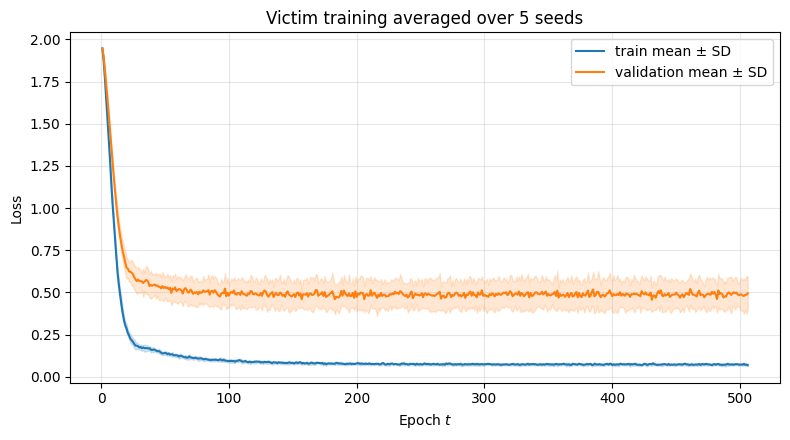

Victim accuracy over 5 seeds: 83.74% ± 1.16% SD


,n_seeds,clean_accuracy_mean,clean_accuracy_std,clean_accuracy_count,clean_accuracy_sem,n_train_epochs_mean,n_train_epochs_std,n_train_epochs_count,n_train_epochs_sem,n_val_epochs_mean,n_val_epochs_std,n_val_epochs_count,n_val_epochs_sem
0,5,0.837391,0.011553,5,0.005167,603.4,127.388383,5,56.969817,603.4,127.388383,5,56.969817


In [4]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

seed_contexts = []
train_curve_rows = []
train_summary_rows = []

for seed in SEEDS:
    set_global_seed(seed)
    print(f"Training victim model for seed={seed}")

    stats = experiment_train.run(
        data_dir='./data',
        dataset=DATASET,
        model_params=dict(
            label=MODEL_LABEL,
            model=MODEL_NAME,
            do_cache_adj_prep=True,
            n_filters=64,
            dropout=DROPOUT_VICTIM,
            svd_params=None,
            jaccard_params=None,
            gdc_params={"alpha": 0.15, "k": 64},
        ),
        train_params=dict(
            lr=LR_VICTIM,
            weight_decay=WEIGHT_DECAY_VICTIM,
            patience=PATIENCE_VICTIM,
            max_epochs=MAX_EPOCHS_VICTIM,
        ),
        binary_attr=False,
        make_undirected=True,
        seed=seed,
        artifact_dir='cache',
        model_storage_type='demo_custom_split',
        ppr_cache_params=dict(),
        device="cpu",
        data_device="cpu",
        display_steps=100,
        debug_level="info",
        custom_split_ratios=None,
    )

    model_seed = stats["model"]
    graph_seed = stats["graph"]
    idx_train_seed = stats["idx_train"]
    idx_val_seed = stats["idx_val"]
    idx_test_seed = stats["idx_test"]
    model_seed.eval()

    attr_matrix_seed, adj_matrix_seed, labels_raw_seed = graph_seed[:3]
    model_device = next(model_seed.parameters()).device
    row, col, value = adj_matrix_seed.coo()
    edge_index_seed = torch.stack([row, col], dim=0).long().to(model_device)
    edge_weight_seed = (
        torch.ones(edge_index_seed.size(1), dtype=torch.float32, device=model_device)
        if value is None else value.float().to(model_device)
    )
    attr_seed = attr_matrix_seed.float().to(model_device)
    labels_seed = labels_raw_seed.long().to(model_device)
    n_nodes_seed = int(adj_matrix_seed.sizes()[0])
    n_edges_directed_seed = int(adj_matrix_seed.nnz())
    n_undirected_seed = n_edges_directed_seed // 2
    clean_acc_seed = float(stats["accuracy"])

    context = {
        "seed": int(seed),
        "train_statistics": stats,
        "clean_acc": clean_acc_seed,
        "model": model_seed,
        "graph": graph_seed,
        "idx_train": idx_train_seed,
        "idx_val": idx_val_seed,
        "idx_test": idx_test_seed,
        "device": model_device,
        "n_nodes": n_nodes_seed,
        "n_edges_directed": n_edges_directed_seed,
        "n_undirected": n_undirected_seed,
        "attr_matrix": attr_matrix_seed,
        "adj_matrix": adj_matrix_seed,
        "labels_raw": labels_raw_seed,
        "edge_index": edge_index_seed,
        "edge_weight": edge_weight_seed,
        "attr": attr_seed,
        "labels": labels_seed,
    }
    seed_contexts.append(context)

    for split, values in (
        ("train", stats.get("trace_train", [])),
        ("validation", stats.get("trace_val", [])),
    ):
        for epoch, loss in enumerate(values, start=1):
            train_curve_rows.append({
                "seed": int(seed),
                "split": split,
                "epoch": int(epoch),
                "loss": float(loss),
            })

    train_summary_rows.append({
        "seed": int(seed),
        "clean_accuracy": clean_acc_seed,
        "n_train_epochs": len(stats.get("trace_train", [])),
        "n_val_epochs": len(stats.get("trace_val", [])),
    })

SEED_CONTEXTS = seed_contexts
SEED_CONTEXT_BY_SEED = {context["seed"]: context for context in seed_contexts}
activate_seed_context(seed_contexts[0])

train_curve_df = pd.DataFrame(train_curve_rows)
train_summary_raw_df = pd.DataFrame(train_summary_rows)
train_summary_df = aggregate_over_seeds(
    train_summary_raw_df,
    group_cols=[],
    metric_cols=["clean_accuracy", "n_train_epochs", "n_val_epochs"],
)

curve_summary = (
    train_curve_df.groupby(["split", "epoch"], as_index=False)
    .agg(loss_mean=("loss", "mean"), loss_std=("loss", "std"), n_seeds=("seed", "nunique"))
)
curve_summary["loss_std"] = curve_summary["loss_std"].fillna(0.0)
curve_summary = curve_summary[curve_summary["n_seeds"] == N_SEEDS].copy()
if curve_summary.empty:
    raise RuntimeError("No victim-training epochs are shared by every configured seed.")

fig, ax = plt.subplots(figsize=(8, 4.5))
for split, group in curve_summary.groupby("split", sort=False):
    group = group.sort_values("epoch")
    add_mean_std_band(
        ax,
        group["epoch"],
        group["loss_mean"],
        group["loss_std"],
        label=f"{split} mean ± SD",
    )
ax.set_xlabel('Epoch $t$')
ax.set_ylabel("Loss")
ax.set_title(f"Victim training averaged over {N_SEEDS} seeds")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

clean_mean = train_summary_raw_df["clean_accuracy"].mean()
clean_std = train_summary_raw_df["clean_accuracy"].std(ddof=1) if N_SEEDS > 1 else 0.0
print(f"Victim accuracy over {N_SEEDS} seeds: {100*clean_mean:.2f}% ± {100*clean_std:.2f}% SD")
display(train_summary_df)


In [5]:
import torch

# Dataset structure is seed-invariant; inspect the first trained context.
activate_seed_context(SEED_CONTEXTS[0])
attr_matrix, adj_matrix, labels_raw = graph[:3]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Display ────────────────────────────────────────────────────────────────
n_nodes = adj_matrix.sizes()[0]
n_edges_directed = adj_matrix.nnz()
n_undirected = n_edges_directed // 2

print(f"nodes={n_nodes}")
print(f"Directed edges: {n_edges_directed}")
print(f"Undirected edges: {n_undirected}")
print(f"features={attr_matrix.shape}")
print(f"classes={len(torch.unique(labels_raw))}")

# ── Convert adjacency SparseTensor -> edge_index / edge_weight ─────────────
row, col, value = adj_matrix.coo()

edge_index = torch.stack([row, col], dim=0).long().to(device)

if value is None:
    edge_weight = torch.ones(edge_index.size(1), dtype=torch.float32, device=device)
else:
    edge_weight = value.float().to(device)

# ── Convert features / labels ──────────────────────────────────────────────
attr = attr_matrix.float().to(device)
labels = labels_raw.long().to(device)

# ── Safety checks ──────────────────────────────────────────────────────────
print("edge_index shape:", edge_index.shape)
print("edge_weight shape:", edge_weight.shape)
print("max node id in edge_index:", int(edge_index.max()))
print("n_nodes:", n_nodes)

assert int(edge_index.max()) < n_nodes
assert attr.shape[0] == n_nodes
assert labels.shape[0] == n_nodes
'''
train_idx_np, val_idx_np, test_idx_np = train_val_test_split(
    graph.labels,
    train_size=0.05,
    val_size=0.05,
    test_size=0.9,
    mode="stratified",
    seed=SEED,
)

train_idx = torch.as_tensor(train_idx_np, dtype=torch.long, device=device)
val_idx = torch.as_tensor(val_idx_np, dtype=torch.long, device=device)
test_idx = torch.as_tensor(test_idx_np, dtype=torch.long, device=device)'''

nodes=2810
Directed edges: 15962
Undirected edges: 7981
features=torch.Size([2810, 2879])
classes=7
edge_index shape: torch.Size([2, 15962])
edge_weight shape: torch.Size([15962])
max node id in edge_index: 2809
n_nodes: 2810


'\ntrain_idx_np, val_idx_np, test_idx_np = train_val_test_split(\n    graph.labels,\n    train_size=0.05,\n    val_size=0.05,\n    test_size=0.9,\n    mode="stratified",\n    seed=SEED,\n)\n\ntrain_idx = torch.as_tensor(train_idx_np, dtype=torch.long, device=device)\nval_idx = torch.as_tensor(val_idx_np, dtype=torch.long, device=device)\ntest_idx = torch.as_tensor(test_idx_np, dtype=torch.long, device=device)'

In [6]:
from helpers.selector_pipeline_helpers import EndpointPRBCDV4Scorer, _edge_set
from IPython.display import display
import math
import random
import pandas as pd


def _safe_config_value(value):
    text = f"{value:.12g}" if isinstance(value, float) else str(value)
    return (text.strip().replace(" ", "").replace("/", "-").replace("\\", "-")
            .replace(".", "p").replace("+", "").replace("-", "m"))


def _resolve_candidate_set_sizes():
    configured = globals().get("CANDIDATE_SET_SIZES", None)
    if configured is None:
        fallback_size = max(1, round(SEED_CONTEXTS[0]["n_undirected"] * PRBCD_BUDGET_FRACTION * N_PRBCD_RUNS))
        return [fallback_size]
    if isinstance(configured, int):
        configured = [configured]
    sizes = [int(value) for value in configured]
    if not sizes or any(size <= 0 for size in sizes):
        raise ValueError("CANDIDATE_SET_SIZES must contain positive values.")
    return sizes


def _resolve_prbcd_candidate_fractions():
    configured = globals().get("PRBCD_CANDIDATE_FRACTIONS", [globals().get("PRBCD_CANDIDATE_FRACTION", 0.5)])
    if isinstance(configured, (int, float)):
        configured = [configured]
    fractions = [float(value) for value in configured]
    if not fractions or any(not 0.0 <= fraction <= 1.0 for fraction in fractions):
        raise ValueError("PRBCD_CANDIDATE_FRACTIONS must be in [0, 1].")
    return fractions


def _candidate_config_id(candidate_set_size: int, prbcd_candidate_fraction: float) -> str:
    return (f"candN-{_safe_config_value(candidate_set_size)}"
            f"__prbcdFrac-{_safe_config_value(prbcd_candidate_fraction)}")


def sample_random_candidates(num_nodes: int, count: int, *, forbidden=None, seed: int):
    forbidden = set() if forbidden is None else set(forbidden)
    n_possible = num_nodes * (num_nodes - 1) // 2
    n_available = n_possible - len(forbidden)
    if count > n_available:
        raise ValueError(f"Cannot sample {count} candidates; only {n_available} remain.")
    rng = random.Random(int(seed))
    sampled = set()
    while len(sampled) < count:
        u, v = rng.randrange(num_nodes), rng.randrange(num_nodes)
        if u == v:
            continue
        edge = (min(u, v), max(u, v))
        if edge not in forbidden:
            sampled.add(edge)
    return sampled


candidate_set_sizes = _resolve_candidate_set_sizes()
prbcd_candidate_fractions = _resolve_prbcd_candidate_fractions()
candidate_runs = []
_candidate_mining_cache = {}

for context in SEED_CONTEXTS:
    activate_seed_context(context)
    seed = context["seed"]
    set_global_seed(seed)
    n_possible_candidates = n_nodes * (n_nodes - 1) // 2
    orig_edges = _edge_set(edge_index)

    for size_index, candidate_set_size in enumerate(candidate_set_sizes):
        if candidate_set_size > n_possible_candidates:
            raise ValueError(f"candidate_set_size={candidate_set_size} exceeds {n_possible_candidates} pairs.")
        budget = max(1, math.ceil(candidate_set_size / max(1, int(N_PRBCD_RUNS))))
        prbcd_budget_fraction = budget / max(1, int(n_undirected))

        for fraction_index, prbcd_candidate_fraction in enumerate(prbcd_candidate_fractions):
            config_id = _candidate_config_id(candidate_set_size, prbcd_candidate_fraction)
            target_prbcd_count = round(candidate_set_size * prbcd_candidate_fraction)
            prbcd_candidates = set()

            if USE_PRBCD_CANDIDATES and target_prbcd_count > 0:
                cache_key = (seed, candidate_set_size)
                if cache_key not in _candidate_mining_cache:
                    scorer = EndpointPRBCDV4Scorer(
                        n=n_nodes, edge_index=edge_index, edge_weight=edge_weight,
                        attr=attr, labels=labels, attacked_model=model,
                        idx_attack=idx_test, test_idx=idx_val, device=device,
                        block_size=PRBCD_SEARCH_SPACE,
                        n_epochs_resampling=PRBCD_N_EPOCHS_RESAMPLING,
                        n_subsets=N_SUBSETS, subset_fraction=SUBSET_FRACTION,
                        balance_ratio=BALANCE_RATIO, store_candidates=True,
                    )
                    mined = scorer.mine_prbcd_endpoint_candidates(
                        n_perturbations=budget,
                        tag=f"endpointPRBCD__{config_id}__seed-{seed}",
                        rng_seed=seed,
                        n_candidates=PRBCD_SEARCH_SPACE,
                        prbcd_epochs=PRBCD_EPOCHS,
                        n_prbcd_runs=N_PRBCD_RUNS,
                        n_epochs_resampling=PRBCD_N_EPOCHS_RESAMPLING,
                    )
                    _candidate_mining_cache[cache_key] = {
                        (min(int(u), int(v)), max(int(u), int(v)))
                        for u, v in mined if int(u) != int(v)
                    }
                prbcd_candidates = set(_candidate_mining_cache[cache_key])

            selection_rng = random.Random(seed + 10_000 * size_index + 101 * fraction_index)
            selected_prbcd = (
                set(selection_rng.sample(sorted(prbcd_candidates), target_prbcd_count))
                if len(prbcd_candidates) > target_prbcd_count else set(prbcd_candidates)
            )
            n_random_needed = candidate_set_size - len(selected_prbcd)
            random_candidates = sample_random_candidates(
                n_nodes, n_random_needed, forbidden=selected_prbcd,
                seed=seed + 20_000 * size_index + 211 * fraction_index + 17,
            )
            candidates_for_config = list(selected_prbcd | random_candidates)
            selection_rng.shuffle(candidates_for_config)
            if len(candidates_for_config) != candidate_set_size:
                raise RuntimeError(f"Expected {candidate_set_size} candidates, got {len(candidates_for_config)}")

            n_removals = sum(edge in orig_edges for edge in candidates_for_config)
            candidate_runs.append({
                "seed": int(seed),
                "context": context,
                "candidate_config_id": config_id,
                "candidate_set_size": int(candidate_set_size),
                "prbcd_candidate_fraction": float(prbcd_candidate_fraction),
                "budget": int(budget),
                "prbcd_budget_fraction": float(prbcd_budget_fraction),
                "n_prbcd_requested": int(target_prbcd_count),
                "n_prbcd_mined_unique": int(len(prbcd_candidates)),
                "n_prbcd_selected": int(len(selected_prbcd)),
                "n_random_candidates": int(len(random_candidates)),
                "actual_prbcd_fraction": float(len(selected_prbcd) / len(candidates_for_config)),
                "n_add_candidates": int(len(candidates_for_config) - n_removals),
                "n_delete_candidates": int(n_removals),
                "candidates": candidates_for_config,
                "selected_prbcd": selected_prbcd,
                "random_candidates": random_candidates,
            })

if not candidate_runs:
    raise RuntimeError("No candidate configurations were created.")

candidate_config_raw_df = pd.DataFrame([
    {key: value for key, value in run.items()
     if key not in {"context", "candidates", "selected_prbcd", "random_candidates"}}
    for run in candidate_runs
])
_candidate_group_cols = ["candidate_config_id", "candidate_set_size", "prbcd_candidate_fraction"]
_candidate_metric_cols = [
    "budget", "prbcd_budget_fraction", "n_prbcd_requested", "n_prbcd_mined_unique",
    "n_prbcd_selected", "n_random_candidates", "actual_prbcd_fraction",
    "n_add_candidates", "n_delete_candidates",
]
candidate_config_df = aggregate_over_seeds(candidate_config_raw_df, _candidate_group_cols, _candidate_metric_cols)
display(candidate_config_df)

candidate_runs_by_key = {(run["seed"], run["candidate_config_id"]): run for run in candidate_runs}
print(f"Created {len(candidate_runs)} raw candidate runs = {len(SEEDS)} seeds × "
      f"{len(candidate_set_sizes)} sizes × {len(prbcd_candidate_fractions)} fractions.")


[endpointPRBCD__candN-5000__prbcdFrac-0p25__seed-0] Mining actual endpointPRBCD flips: budget=834, block=200000, epochs=5, runs=6
[endpointPRBCD__candN-5000__prbcdFrac-0p25__seed-0] PRBCD run 1/6 (seed=0)
[endpointPRBCD] epochs=5, epochs_resampling=2, fine_tuning_epochs=3
run sampling with no certificate
GCN(
  (activation): ReLU()
  (layers): ModuleList(
    (0): Sequential(
      (gcn_0): ChainableGCNConv(2879, 64)
      (activation_0): ReLU()
      (dropout_0): Dropout(p=0.5, inplace=False)
    )
    (1): Sequential(
      (gcn_1): ChainableGCNConv(64, 7)
    )
  )
)


[07/10/26 09:07:41] INFO                                                           ]8;id=271493;file:///home/hschult5/AttackerGNN/helpers/selector_pipeline_helpers.py\selector_pipeline_helpers.py]8;;\:]8;id=536110;file:///home/hschult5/AttackerGNN/helpers/selector_pipeline_helpers.py#618\618]8;;\
                             Before mining - Loss: -0.6458607912063599 Accuracy:                                   
                             83.281 %                                                                              
                                                                                                                   

  0%|          | 0/5 [00:00<?, ?it/s]

                    INFO                                                           ]8;id=318046;file:///home/hschult5/AttackerGNN/helpers/selector_pipeline_helpers.py\selector_pipeline_helpers.py]8;;\:]8;id=499748;file:///home/hschult5/AttackerGNN/helpers/selector_pipeline_helpers.py#693\693]8;;\
                             Epoch: 0 Loss: -0.6458 Accuracy: 81.304 %                                             
                                                                                                                   

[endpointPRBCD] Final discrete attack selected 834 actual flips.
[endpointPRBCD__candN-5000__prbcdFrac-0p25__seed-0] Run 1: 834 flips, 834 new, 834 total unique
[endpointPRBCD__candN-5000__prbcdFrac-0p25__seed-0] PRBCD run 2/6 (seed=1)
[endpointPRBCD] epochs=5, epochs_resampling=2, fine_tuning_epochs=3
run sampling with no certificate
GCN(
  (activation): ReLU()
  (layers): ModuleList(
    (0): Sequential(
      (gcn_0): ChainableGCNConv(2879, 64)
      (activation_0): ReLU()
      (dropout_0): Dropout(p=0.5, inplace=False)
    )
    (1): Sequential(
      (gcn_1): ChainableGCNConv(64, 7)
    )
  )
)


...

  0%|          | 0/5 [00:00<?, ?it/s]

                    INFO                                                           ]8;id=481316;file:///home/hschult5/AttackerGNN/helpers/selector_pipeline_helpers.py\selector_pipeline_helpers.py]8;;\:]8;id=26923;file:///home/hschult5/AttackerGNN/helpers/selector_pipeline_helpers.py#693\693]8;;\
                             Epoch: 0 Loss: -0.6593 Accuracy: 80.909 %                                             
                                                                                                                   

[endpointPRBCD] Final discrete attack selected 1667 actual flips.
[endpointPRBCD__candN-10000__prbcdFrac-0p25__seed-4] Run 6: 1667 flips, 1338 new, 9018 total unique
[endpointPRBCD__candN-10000__prbcdFrac-0p25__seed-4] Mined 9018 unique actual PRBCD flips.


,candidate_config_id,candidate_set_size,prbcd_candidate_fraction,budget_mean,budget_std,budget_count,prbcd_budget_fraction_mean,prbcd_budget_fraction_std,prbcd_budget_fraction_count,n_prbcd_requested_mean,...,budget_sem,prbcd_budget_fraction_sem,n_prbcd_requested_sem,n_prbcd_mined_unique_sem,n_prbcd_selected_sem,n_random_candidates_sem,actual_prbcd_fraction_sem,n_add_candidates_sem,n_delete_candidates_sem,n_seeds
0,candN-10000__prbcdFrac-0p25,10000,0.25,1667.0,0.0,5,0.208871,0.0,5,2500.0,...,0.0,0.0,0.0,16.854080,0.0,0.0,0.0,2.111871,2.111871,5
1,candN-10000__prbcdFrac-0p75,10000,0.75,1667.0,0.0,5,0.208871,0.0,5,7500.0,...,0.0,0.0,0.0,16.854080,0.0,0.0,0.0,1.673320,1.673320,5
2,candN-5000__prbcdFrac-0p25,5000,0.25,834.0,0.0,5,0.104498,0.0,5,1250.0,...,0.0,0.0,0.0,6.858571,0.0,0.0,0.0,1.749286,1.749286,5
3,candN-5000__prbcdFrac-0p75,5000,0.75,834.0,0.0,5,0.104498,0.0,5,3750.0,...,0.0,0.0,0.0,6.858571,0.0,0.0,0.0,0.871780,0.871780,5


Created 20 raw candidate runs = 5 seeds × 2 sizes × 2 fractions.


,candidate_config_id,candidate_set_size,prbcd_candidate_fraction,actual_prbcd_fraction_mean,actual_prbcd_fraction_std,actual_prbcd_fraction_count,n_candidate_endpoint_nodes_mean,n_candidate_endpoint_nodes_std,n_candidate_endpoint_nodes_count,mean_candidate_endpoint_degree_mean,...,n_delete_candidates_std,n_delete_candidates_count,actual_prbcd_fraction_sem,n_candidate_endpoint_nodes_sem,mean_candidate_endpoint_degree_sem,median_candidate_endpoint_degree_sem,max_candidate_endpoint_degree_sem,n_add_candidates_sem,n_delete_candidates_sem,n_seeds
0,candN-10000__prbcdFrac-0p25,10000,0.25,0.25,0.0,5,2802.0,3.082207,5,5.673305,...,4.722288,5,0.0,1.378405,0.003704,0.0,0.000000,2.111871,2.111871,5
1,candN-10000__prbcdFrac-0p75,10000,0.75,0.75,0.0,5,2704.4,8.018728,5,5.472363,...,3.741657,5,0.0,3.586084,0.049147,0.2,23.025204,1.673320,1.673320,5
2,candN-5000__prbcdFrac-0p25,5000,0.25,0.25,0.0,5,2693.6,11.458621,5,5.632753,...,3.911521,5,0.0,5.124451,0.014088,0.0,0.000000,1.749286,1.749286,5
3,candN-5000__prbcdFrac-0p75,5000,0.75,0.75,0.0,5,2364.6,30.541775,5,5.183410,...,1.949359,5,0.0,13.658697,0.041290,0.0,18.800000,0.871780,0.871780,5


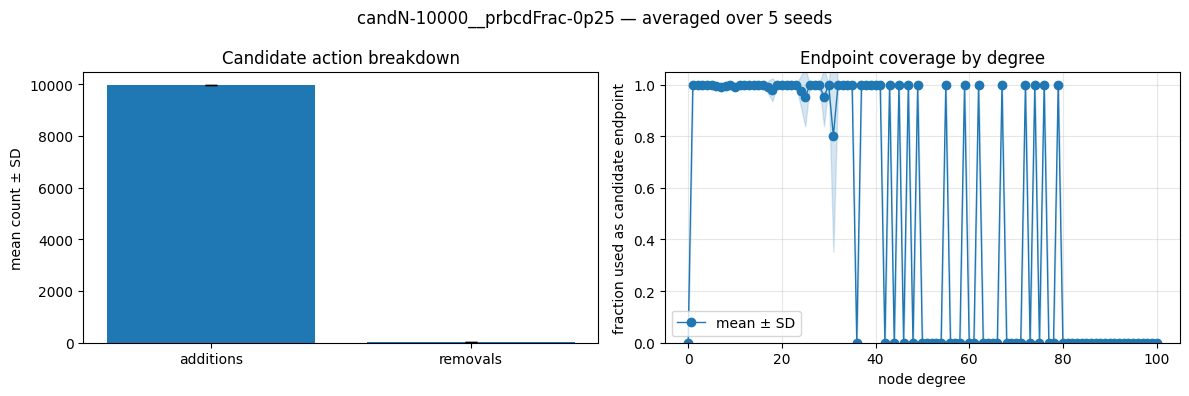

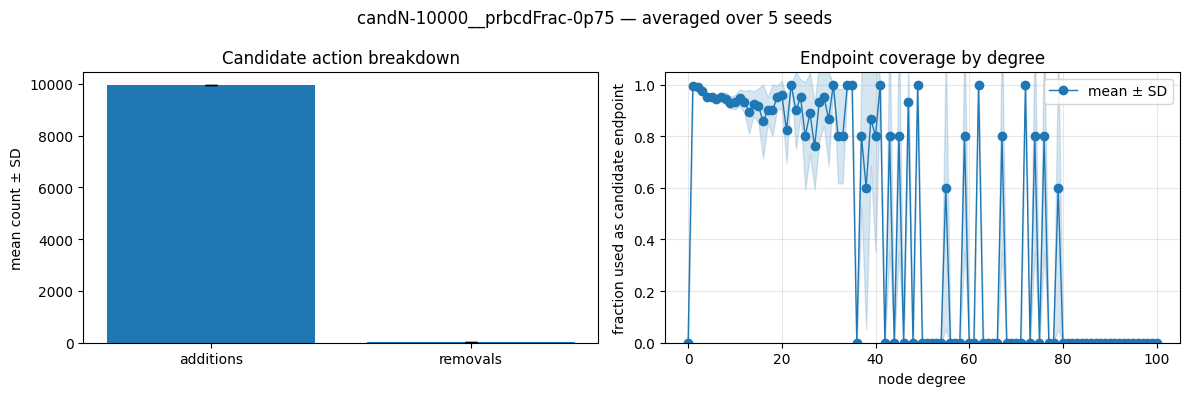

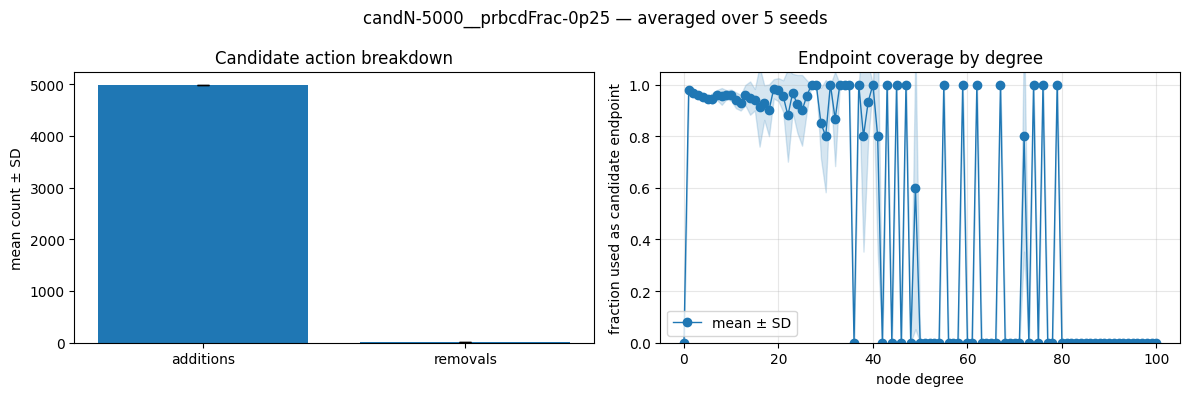

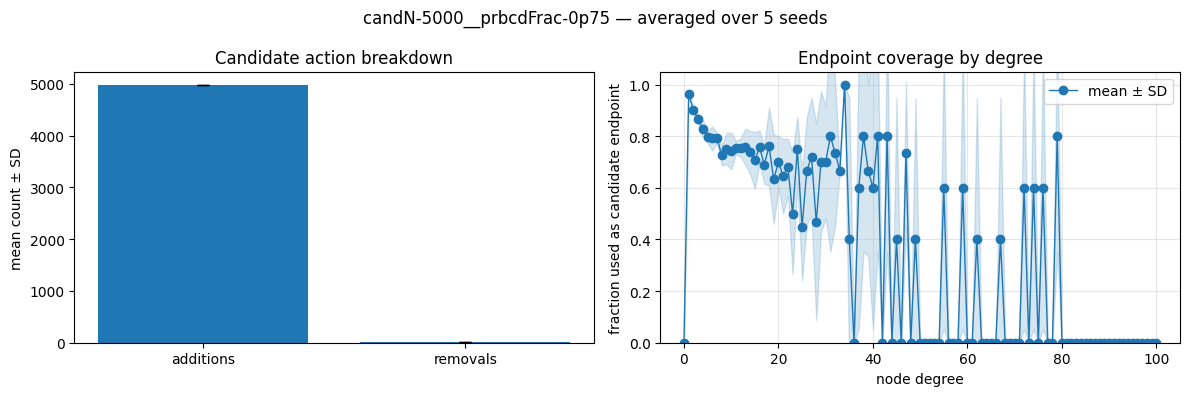

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CANDIDATE_DIAGNOSTIC_OUT_DIR = Path("extendedPlotting") / "candidate_diagnostics_multiseed"
CANDIDATE_DIAGNOSTIC_OUT_DIR.mkdir(parents=True, exist_ok=True)

candidate_degree_summary_rows = []
degree_profile_rows = []

for run in candidate_runs:
    context = run["context"]
    degrees_run = np.bincount(context["edge_index"][0].cpu().numpy(), minlength=context["n_nodes"])
    candidates_run = run["candidates"]
    cand_nodes = sorted(set(u for u, v in candidates_run) | set(v for u, v in candidates_run))
    cand_degs = degrees_run[cand_nodes] if cand_nodes else np.array([], dtype=int)
    endpoint_mask = np.zeros(context["n_nodes"], dtype=bool)
    endpoint_mask[cand_nodes] = True
    all_counts = np.bincount(degrees_run)
    endpoint_counts = np.bincount(degrees_run[endpoint_mask], minlength=len(all_counts))
    fractions = np.divide(endpoint_counts, all_counts, out=np.zeros_like(endpoint_counts, dtype=float), where=all_counts > 0)

    candidate_degree_summary_rows.append({
        "seed": run["seed"],
        "candidate_config_id": run["candidate_config_id"],
        "candidate_set_size": run["candidate_set_size"],
        "prbcd_candidate_fraction": run["prbcd_candidate_fraction"],
        "actual_prbcd_fraction": run["actual_prbcd_fraction"],
        "n_candidate_endpoint_nodes": len(cand_nodes),
        "mean_candidate_endpoint_degree": float(cand_degs.mean()) if cand_degs.size else np.nan,
        "median_candidate_endpoint_degree": float(np.median(cand_degs)) if cand_degs.size else np.nan,
        "max_candidate_endpoint_degree": float(cand_degs.max()) if cand_degs.size else np.nan,
        "n_add_candidates": run["n_add_candidates"],
        "n_delete_candidates": run["n_delete_candidates"],
    })
    for degree, (all_count, endpoint_count, fraction) in enumerate(zip(all_counts, endpoint_counts, fractions)):
        degree_profile_rows.append({
            "seed": run["seed"], "candidate_config_id": run["candidate_config_id"],
            "degree": degree, "all_node_count": all_count,
            "candidate_endpoint_count": endpoint_count, "candidate_endpoint_fraction": fraction,
        })

candidate_degree_raw_df = pd.DataFrame(candidate_degree_summary_rows)
candidate_degree_summary_df = aggregate_over_seeds(
    candidate_degree_raw_df,
    ["candidate_config_id", "candidate_set_size", "prbcd_candidate_fraction"],
    ["actual_prbcd_fraction", "n_candidate_endpoint_nodes", "mean_candidate_endpoint_degree",
     "median_candidate_endpoint_degree", "max_candidate_endpoint_degree",
     "n_add_candidates", "n_delete_candidates"],
)
candidate_degree_raw_df.to_csv(CANDIDATE_DIAGNOSTIC_OUT_DIR / "candidate_degree_summary_raw.csv", index=False)
candidate_degree_summary_df.to_csv(CANDIDATE_DIAGNOSTIC_OUT_DIR / "candidate_degree_summary_averaged.csv", index=False)
display(candidate_degree_summary_df)

degree_profile_raw_df = pd.DataFrame(degree_profile_rows)
degree_profile_df = aggregate_over_seeds(
    degree_profile_raw_df, ["candidate_config_id", "degree"],
    ["all_node_count", "candidate_endpoint_count", "candidate_endpoint_fraction"],
)

for config_id, summary_group in candidate_degree_summary_df.groupby("candidate_config_id", sort=False):
    summary = summary_group.iloc[0]
    profile = degree_profile_df[degree_profile_df["candidate_config_id"] == config_id].sort_values("degree")
    profile = profile[profile["degree"] <= min(100, profile["degree"].max())]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    labels_bar = ["additions", "removals"]
    means = [summary["n_add_candidates_mean"], summary["n_delete_candidates_mean"]]
    stds = [summary["n_add_candidates_std"], summary["n_delete_candidates_std"]]
    axes[0].bar(labels_bar, means, yerr=stds, capsize=4)
    axes[0].set_ylabel("mean count ± SD")
    axes[0].set_title("Candidate action breakdown")

    add_mean_std_band(
        axes[1], profile["degree"], profile["candidate_endpoint_fraction_mean"],
        profile["candidate_endpoint_fraction_std"], label="mean ± SD", marker="o", linewidth=1,
    )
    axes[1].set_xlabel("node degree")
    axes[1].set_ylabel("fraction used as candidate endpoint")
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    axes[1].set_title("Endpoint coverage by degree")
    fig.suptitle(f"{config_id} — averaged over {N_SEEDS} seeds")
    fig.tight_layout()
    fig.savefig(CANDIDATE_DIAGNOSTIC_OUT_DIR / f"candidate_diagnostics__{_safe_config_value(config_id)}.png", dpi=200, bbox_inches="tight")
    plt.show()


In [8]:
# Debug breakpoint removed in the multiseed notebook.

---
## §2  Subset Scoring

We run `N_SUBSETS` random subsets of the candidate pool, apply each subset jointly, and measure test-accuracy drop.  Each edge accumulates the drops of every subset it was in; the raw scores are normalised globally to [0, 1].

**Key diagnostics:**
- Accuracy drop per subset — are subsets actually harming the model?
- Distribution of raw accumulated scores — how skewed is it?
- Fraction of candidates with score > 0 — coverage.

In [9]:
# PATCH: h-hop endpoint mining monkey patch
# Keeps endpoint_mining_hop/h available inside the notebook even if the helper
# module was loaded before the h-hop implementation was edited.
from typing import Any
import torch
import helpers.selector_pipeline_helpers as _selector_helpers


@torch.no_grad()
def _mine_endpoint_flips_with_h(
    *,
    model: torch.nn.Module,
    attr: torch.Tensor,
    labels: torch.Tensor,
    adj_orig: torch.Tensor,
    cand_src: torch.Tensor,
    cand_dst: torch.Tensor,
    clean_preds: torch.Tensor,
    clean_correct: torch.Tensor,
    clean_accuracy: float,
    h: int = 0,
    verbose: bool = True,
) -> dict[str, Any]:
    """
    Evaluate every original candidate edge exactly once.

    h = 0: query the full graph.
    h > 0: query only the h-hop neighborhood around the candidate endpoints.

    If the local subgraph is too small for a victim GCN with GDC/PPR top-k
    preprocessing, the query falls back to the full graph for that candidate.
    """
    if h < 0:
        raise ValueError("h must be non-negative. Use h=0 for the full graph.")

    device = adj_orig.device

    attr = attr.to(device)
    labels = labels.to(device=device, dtype=torch.long)
    cand_src = cand_src.to(device=device, dtype=torch.long).view(-1)
    cand_dst = cand_dst.to(device=device, dtype=torch.long).view(-1)
    clean_preds = clean_preds.to(device=device, dtype=torch.long)
    clean_correct = clean_correct.to(device=device, dtype=torch.bool)

    if cand_src.numel() != cand_dst.numel():
        raise ValueError("cand_src and cand_dst must have equal length.")

    n_samples = cand_src.numel()
    if n_samples == 0:
        raise ValueError("The candidate list is empty.")

    def _h_hop_nodes_from_dense_adj(adj: torch.Tensor, seeds: torch.Tensor, num_hops: int) -> torch.Tensor:
        seeds = seeds.to(device=adj.device, dtype=torch.long).view(-1)
        n_nodes = adj.size(0)

        visited = torch.zeros(n_nodes, device=adj.device, dtype=torch.bool)
        frontier = torch.zeros_like(visited)
        visited[seeds] = True
        frontier[seeds] = True

        adj_bool = adj > 0.5

        for _ in range(num_hops):
            neigh_out = adj_bool[frontier].any(dim=0)
            neigh_in = adj_bool[:, frontier].any(dim=1)
            neighbors = neigh_out | neigh_in
            new_frontier = neighbors & ~visited
            visited |= neighbors
            frontier = new_frontier

            if not bool(frontier.any().item()):
                break

        return torch.nonzero(visited, as_tuple=True)[0]

    def _clear_adj_cache_and_call(x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        # Some rgnn_at_scale GCN variants cache preprocessed adjacency.
        # Candidate flips change adjacency every iteration, so clear it for the call.
        has_cache = hasattr(model, "adj_preped")
        old_cache = getattr(model, "adj_preped", None) if has_cache else None
        try:
            if has_cache:
                model.adj_preped = None
            return model(x, adj)
        finally:
            if has_cache:
                model.adj_preped = old_cache

    def _local_query_is_unsafe_for_gdc(sub_adj: torch.Tensor) -> bool:
        gdc_params = getattr(model, "gdc_params", None)
        if gdc_params is None:
            return False
        if "k" not in gdc_params:
            return False
        try:
            return int(sub_adj.size(0)) < int(gdc_params["k"])
        except Exception:
            return False

    model.eval()
    adj_work = adj_orig.clone()

    endpoint_labels = torch.zeros(n_samples, device=device, dtype=torch.float32)
    src_hit_labels = torch.zeros_like(endpoint_labels)
    dst_hit_labels = torch.zeros_like(endpoint_labels)
    both_hit_labels = torch.zeros_like(endpoint_labels)
    exists_clean = torch.zeros(n_samples, device=device, dtype=torch.bool)

    src_pert_predictions = torch.full((n_samples,), -1, device=device, dtype=torch.long)
    dst_pert_predictions = torch.full_like(src_pert_predictions, -1)
    neighborhood_sizes = torch.zeros(n_samples, device=device, dtype=torch.long)
    used_full_graph_fallback = torch.zeros(n_samples, device=device, dtype=torch.bool)

    rows: list[dict[str, Any]] = []

    for i in range(n_samples):
        u = int(cand_src[i].item())
        v = int(cand_dst[i].item())

        original_uv = float(adj_orig[u, v].item())
        original_vu = float(adj_orig[v, u].item())

        edge_exists = original_uv > 0.5 or original_vu > 0.5
        exists_clean[i] = edge_exists

        flipped_value = 0.0 if edge_exists else 1.0

        # Flip exactly this original candidate edge.
        adj_work[u, v] = flipped_value
        adj_work[v, u] = flipped_value

        neighborhood_size = int(adj_work.size(0))
        full_graph_fallback = False

        if h == 0:
            pert_preds = _clear_adj_cache_and_call(attr, adj_work).argmax(dim=-1)
            u_pert_pred = int(pert_preds[u].item())
            v_pert_pred = int(pert_preds[v].item())
        else:
            sub_nodes = _h_hop_nodes_from_dense_adj(
                adj=adj_work,
                seeds=torch.tensor([u, v], device=device, dtype=torch.long),
                num_hops=h,
            )
            sub_attr = attr[sub_nodes]
            sub_adj = adj_work[sub_nodes][:, sub_nodes]
            neighborhood_size = int(sub_nodes.numel())

            if _local_query_is_unsafe_for_gdc(sub_adj):
                full_graph_fallback = True
            else:
                try:
                    sub_preds = _clear_adj_cache_and_call(sub_attr, sub_adj).argmax(dim=-1)

                    global_to_local = torch.full(
                        (adj_work.size(0),),
                        -1,
                        device=device,
                        dtype=torch.long,
                    )
                    global_to_local[sub_nodes] = torch.arange(
                        sub_nodes.numel(),
                        device=device,
                        dtype=torch.long,
                    )

                    u_local = int(global_to_local[u].item())
                    v_local = int(global_to_local[v].item())
                    u_pert_pred = int(sub_preds[u_local].item())
                    v_pert_pred = int(sub_preds[v_local].item())
                except RuntimeError:
                    # Conservative fallback: keep the run alive and preserve the
                    # victim model's original preprocessing instead of changing it.
                    full_graph_fallback = True

            if full_graph_fallback:
                pert_preds = _clear_adj_cache_and_call(attr, adj_work).argmax(dim=-1)
                u_pert_pred = int(pert_preds[u].item())
                v_pert_pred = int(pert_preds[v].item())

        neighborhood_sizes[i] = neighborhood_size
        used_full_graph_fallback[i] = full_graph_fallback

        u_clean_pred = int(clean_preds[u].item())
        v_clean_pred = int(clean_preds[v].item())
        u_true = int(labels[u].item())
        v_true = int(labels[v].item())

        u_hit = bool(clean_correct[u].item()) and u_pert_pred != u_true
        v_hit = bool(clean_correct[v].item()) and v_pert_pred != v_true
        endpoint_hit = u_hit or v_hit
        both_hit = u_hit and v_hit

        endpoint_labels[i] = float(endpoint_hit)
        src_hit_labels[i] = float(u_hit)
        dst_hit_labels[i] = float(v_hit)
        both_hit_labels[i] = float(both_hit)
        src_pert_predictions[i] = u_pert_pred
        dst_pert_predictions[i] = v_pert_pred

        rows.append({
            "sample_index": i,
            "u": u,
            "v": v,
            "exists_clean": edge_exists,
            "action": "del" if edge_exists else "add",
            "h": int(h),
            "endpoint_mining_hop": int(h),
            "neighborhood_size": neighborhood_size,
            "used_full_graph_fallback": bool(full_graph_fallback),
            "u_label": u_true,
            "v_label": v_true,
            "u_clean_pred": u_clean_pred,
            "v_clean_pred": v_clean_pred,
            "u_pert_pred": u_pert_pred,
            "v_pert_pred": v_pert_pred,
            "u_was_correct": bool(clean_correct[u].item()),
            "v_was_correct": bool(clean_correct[v].item()),
            "u_hit": u_hit,
            "v_hit": v_hit,
            "both_hit": both_hit,
            "endpoint_hit": endpoint_hit,
        })

        # Restore the graph exactly.
        adj_work[u, v] = original_uv
        adj_work[v, u] = original_vu

    endpoint_hits = int(endpoint_labels.sum().item())

    if verbose:
        print(f"Clean evaluation accuracy: {clean_accuracy:.4f}")
        print(f"Original candidate edges evaluated: {n_samples}")
        if h == 0:
            print("Victim queries used the full graph.")
        else:
            print(f"Victim queries used h-hop neighborhoods with h={h}.")
            print(f"Average neighborhood size: {float(neighborhood_sizes.float().mean().item()):.2f}")
            print(f"Full-graph fallbacks: {int(used_full_graph_fallback.sum().item())}/{n_samples}")
        print(f"Endpoint hits: {endpoint_hits}/{n_samples} ({endpoint_hits / n_samples:.2%})")

    edge_index_lab = torch.stack([cand_src, cand_dst], dim=0)

    return {
        "mode": "endpoint",
        "h": int(h),
        "endpoint_mining_hop": int(h),
        "labels_raw": endpoint_labels.detach().cpu().numpy(),
        "labels_norm": endpoint_labels.detach().cpu().numpy(),
        "endpoint_labels": endpoint_labels.detach().cpu().numpy(),
        "sampled_edge_index": edge_index_lab.detach().cpu(),
        "sampled_u": cand_src.detach().cpu().numpy(),
        "sampled_v": cand_dst.detach().cpu().numpy(),
        "u_hit_labels": src_hit_labels.detach().cpu().numpy(),
        "v_hit_labels": dst_hit_labels.detach().cpu().numpy(),
        "both_hit_labels": both_hit_labels.detach().cpu().numpy(),
        "u_pert_predictions": src_pert_predictions.detach().cpu().numpy(),
        "v_pert_predictions": dst_pert_predictions.detach().cpu().numpy(),
        "exists": exists_clean.detach().cpu().numpy(),
        "neighborhood_sizes": neighborhood_sizes.detach().cpu().numpy(),
        "used_full_graph_fallback": used_full_graph_fallback.detach().cpu().numpy(),
        "clean_accuracy": clean_accuracy,
        "endpoint_hits": endpoint_hits,
        "n_samples": n_samples,
        "rows": rows,
    }


_selector_helpers._mine_endpoint_flips = _mine_endpoint_flips_with_h
_selector_helpers.mine_candidate_edge_scores.__globals__["_mine_endpoint_flips"] = _mine_endpoint_flips_with_h
print("Patched helpers.selector_pipeline_helpers._mine_endpoint_flips with h-hop support.")


Patched helpers.selector_pipeline_helpers._mine_endpoint_flips with h-hop support.


In [10]:
from pathlib import Path
from IPython.display import display
import hashlib
import numpy as np
import pandas as pd
import torch

from helpers.selector_pipeline_helpers import (
    mine_candidate_edge_scores, save_mining_output, load_mining_output, _dense_adj,
)


def _resolve_scoring_modes():
    configured = globals().get("SCORING_MODES", [globals().get("SCORING_MODE", "endpoint")])
    if isinstance(configured, str):
        configured = [configured]
    modes = [str(mode) for mode in configured]
    if not modes:
        raise ValueError("SCORING_MODES must not be empty.")
    return modes


def _resolve_endpoint_mining_hops():
    configured = globals().get("ENDPOINT_MINING_HOPS", [0])
    if isinstance(configured, int):
        configured = [configured]
    hops = [int(value) for value in configured]
    if not hops or any(h < 0 for h in hops):
        raise ValueError("ENDPOINT_MINING_HOPS must contain non-negative integers.")
    return hops


scoring_modes = _resolve_scoring_modes()
endpoint_mining_hops = _resolve_endpoint_mining_hops()
mining_runs = []
mining_summary_rows = []

for candidate_run in candidate_runs:
    context = candidate_run["context"]
    activate_seed_context(context)
    seed = candidate_run["seed"]
    set_global_seed(seed)
    adj_orig_run = _dense_adj(edge_index, n_nodes, device=device)
    candidates_for_config = candidate_run["candidates"]
    cand_src = [u for u, v in candidates_for_config]
    cand_dst = [v for u, v in candidates_for_config]
    exists_list = [float(adj_orig_run[u, v].item()) for u, v in candidates_for_config]

    for scoring_mode in scoring_modes:
        for endpoint_h in (endpoint_mining_hops if scoring_mode == "endpoint" else [0]):
            candidate_hash = hashlib.sha1(repr(candidates_for_config).encode("utf-8")).hexdigest()[:10]
            cache_path = Path("cache") / (
                f"candidate_mining_dataset-{DATASET}_model-{MODEL_LABEL}_"
                f"cfg-{candidate_run['candidate_config_id']}_scoringMode-{scoring_mode}_"
                f"h-{endpoint_h}_seed-{seed}_candidates-{len(candidates_for_config)}_hash-{candidate_hash}.pt"
            )
            metadata = {
                "scoring_mode": scoring_mode, "endpoint_mining_hop": int(endpoint_h),
                "seed": int(seed), "n_nodes": int(n_nodes),
                "n_candidates": len(candidates_for_config),
                "candidate_config_id": candidate_run["candidate_config_id"],
                "candidate_set_size": candidate_run["candidate_set_size"],
                "prbcd_candidate_fraction": candidate_run["prbcd_candidate_fraction"],
                "actual_prbcd_fraction": candidate_run["actual_prbcd_fraction"],
                "subset_fraction": float(SUBSET_FRACTION), "n_subsets": int(N_SUBSETS),
                "endpoint_require_correct_to_incorrect": True,
            }
            print(f"Scoring seed={seed} | {candidate_run['candidate_config_id']} | mode={scoring_mode} | h={endpoint_h}")
            if cache_path.exists():
                mining_result, cached_candidates, _ = load_mining_output(
                    cache_path, device=device, expected_metadata=metadata,
                )
                if cached_candidates != candidates_for_config:
                    raise ValueError("Cached candidates differ from current candidates.")
                cache_status = "loaded"
            else:
                mining_result = mine_candidate_edge_scores(
                    model=model, attr=attr, edge_index=edge_index, labels=labels,
                    eval_idx=idx_test, candidates=candidates_for_config, n_nodes=n_nodes,
                    mode=scoring_mode, subset_fraction=SUBSET_FRACTION, n_subsets=N_SUBSETS,
                    endpoint_k_samples=None, endpoint_require_correct_to_incorrect=True,
                    two_hop_k_samples=None, h=endpoint_h, seed=seed, device=device, verbose=True,
                )
                save_mining_output(cache_path, mining_result, candidates=candidates_for_config, metadata=metadata)
                cache_status = "computed"

            labels_raw_run = mining_result["labels_raw"]
            labels_norm_run = mining_result["labels_norm"]
            clean_accuracy = float(mining_result["clean_accuracy"])
            labels_tensor = torch.tensor(labels_norm_run, dtype=torch.float32, device=device)
            if scoring_mode == "endpoint":
                n_positive = int(np.asarray(mining_result["endpoint_labels"]).sum())
                diagnostic_value = float(n_positive / max(1, int(mining_result["n_samples"])))
                diagnostic_name = "endpoint_hit_rate"
            else:
                drop_values = np.asarray(mining_result["drop_per_subset"], dtype=float)
                n_positive = int((labels_tensor > 0).sum().item())
                diagnostic_value = float(drop_values.mean())
                diagnostic_name = "mean_subset_drop"

            run = {
                **{key: value for key, value in candidate_run.items()
                   if key not in {"selected_prbcd", "random_candidates"}},
                "seed": int(seed), "context": context, "adj_orig": adj_orig_run,
                "scoring_mode": scoring_mode, "endpoint_mining_hop": int(endpoint_h),
                "candidate_hash": candidate_hash, "cache_path": str(cache_path),
                "cache_status": cache_status, "cand_src": cand_src, "cand_dst": cand_dst,
                "exists_list": exists_list, "n_cands": len(candidates_for_config),
                "mining_result": mining_result, "labels_raw": labels_raw_run,
                "labels_norm": labels_norm_run, "clean_accuracy": clean_accuracy,
                "src": torch.tensor(cand_src, dtype=torch.long, device=device),
                "dst": torch.tensor(cand_dst, dtype=torch.long, device=device),
                "labels_changed": labels_tensor,
                "exists": torch.tensor(exists_list, dtype=torch.float32, device=device),
                "n_positive_labels": n_positive,
            }
            mining_runs.append(run)
            mining_summary_rows.append({
                "seed": int(seed), "candidate_config_id": candidate_run["candidate_config_id"],
                "candidate_set_size": candidate_run["candidate_set_size"],
                "prbcd_candidate_fraction": candidate_run["prbcd_candidate_fraction"],
                "actual_prbcd_fraction": candidate_run["actual_prbcd_fraction"],
                "scoring_mode": scoring_mode, "endpoint_mining_hop": int(endpoint_h),
                "n_candidates": len(candidates_for_config), "n_positive_labels": n_positive,
                "positive_fraction": n_positive / max(1, len(candidates_for_config)),
                "clean_accuracy": clean_accuracy, diagnostic_name: diagnostic_value,
                "cache_status": cache_status, "cache_path": str(cache_path),
            })

if not mining_runs:
    raise RuntimeError("No mining runs were created.")
mining_summary_raw_df = pd.DataFrame(mining_summary_rows)
mining_group_cols = [
    "candidate_config_id", "candidate_set_size", "prbcd_candidate_fraction",
    "scoring_mode", "endpoint_mining_hop",
]
mining_summary_df = aggregate_over_seeds(
    mining_summary_raw_df, mining_group_cols,
    ["actual_prbcd_fraction", "n_candidates", "n_positive_labels", "positive_fraction",
     "clean_accuracy", "endpoint_hit_rate", "mean_subset_drop"],
)
mining_summary_raw_df.to_csv("extendedPlotting/mining_summary_raw_multiseed.csv", index=False)
mining_summary_df.to_csv("extendedPlotting/mining_summary_averaged_multiseed.csv", index=False)
display(mining_summary_df)
mining_runs_by_key = {
    (run["seed"], run["candidate_config_id"], run["scoring_mode"], run["endpoint_mining_hop"]): run
    for run in mining_runs
}


Scoring seed=0 | candN-5000__prbcdFrac-0p25 | mode=endpoint | h=0
Clean evaluation accuracy: 0.8328
Original candidate edges evaluated: 5000
Victim queries used the full graph.
Endpoint hits: 1213/5000 (24.26%)
[MINING CACHE] Saved mining output to: cache/candidate_mining_dataset-cora_ml_model-GCN_cfg-candN-5000__prbcdFrac-0p25_scoringMode-endpoint_h-0_seed-0_candidates-5000_hash-439abaaba1.pt
Scoring seed=0 | candN-5000__prbcdFrac-0p25 | mode=endpoint | h=2
Clean evaluation accuracy: 0.8328
Original candidate edges evaluated: 5000
Victim queries used h-hop neighborhoods with h=2.
Average neighborhood size: 132.80
Full-graph fallbacks: 1745/5000
Endpoint hits: 1289/5000 (25.78%)
[MINING CACHE] Saved mining output to: cache/candidate_mining_dataset-cora_ml_model-GCN_cfg-candN-5000__prbcdFrac-0p25_scoringMode-endpoint_h-2_seed-0_candidates-5000_hash-439abaaba1.pt
Scoring seed=0 | candN-5000__prbcdFrac-0p25 | mode=subset_accuracy_drop | h=0
Clean evaluation accuracy: 0.8328
Subset size: 2

KeyboardInterrupt: 

In [ ]:
subset_runs = [run for run in mining_runs if run["scoring_mode"] == "subset_accuracy_drop"]

if subset_runs:
    from pathlib import Path
    out_dir = Path("extendedPlotting") / "subset_scoring_multiseed"
    out_dir.mkdir(parents=True, exist_ok=True)
    group_keys = ["candidate_config_id", "candidate_set_size", "prbcd_candidate_fraction", "endpoint_mining_hop"]
    for key, runs in pd.DataFrame([{**{k: r[k] for k in group_keys}, "run": r} for r in subset_runs]).groupby(group_keys, dropna=False):
        run_list = runs["run"].tolist()
        subset_rows, label_arrays = [], []
        for run in run_list:
            drops = np.asarray(run["mining_result"]["drop_per_subset"], dtype=float)
            subset_rows.extend({"seed": run["seed"], "subset_index": i + 1, "drop": value} for i, value in enumerate(drops))
            label_arrays.append(np.asarray(run["labels_raw"], dtype=float))
        subset_df = pd.DataFrame(subset_rows)
        curve = subset_df.groupby("subset_index", as_index=False).agg(drop_mean=("drop", "mean"), drop_std=("drop", "std"))
        curve["drop_std"] = curve["drop_std"].fillna(0.0)
        all_drops = subset_df["drop"].to_numpy()
        drop_bins = np.linspace(all_drops.min(), all_drops.max() + 1e-12, 21)
        hist_drop = np.vstack([np.histogram(subset_df.loc[subset_df.seed == seed, "drop"], bins=drop_bins)[0] for seed in sorted(subset_df.seed.unique())])
        positives = [arr[arr > 0] for arr in label_arrays]
        pooled_pos = np.concatenate([arr for arr in positives if arr.size]) if any(arr.size for arr in positives) else np.array([0.0])
        label_bins = np.linspace(pooled_pos.min(), pooled_pos.max() + 1e-12, 31)
        hist_label = np.vstack([np.histogram(arr, bins=label_bins)[0] for arr in positives])

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        add_mean_std_band(axes[0], curve.subset_index, curve.drop_mean, curve.drop_std, label="mean ± SD", marker="o", markersize=3)
        axes[0].set_xlabel("subset index"); axes[0].set_ylabel("accuracy drop"); axes[0].legend(); axes[0].grid(True, alpha=.3)
        centers = (drop_bins[:-1] + drop_bins[1:]) / 2
        axes[1].step(centers, hist_drop.mean(0), where="mid", label="mean count")
        axes[1].fill_between(centers, hist_drop.mean(0)-hist_drop.std(0), hist_drop.mean(0)+hist_drop.std(0), alpha=.18, step="mid")
        axes[1].set_xlabel("accuracy drop"); axes[1].set_ylabel("mean bin count ± SD")
        centers_l = (label_bins[:-1] + label_bins[1:]) / 2
        axes[2].step(centers_l, hist_label.mean(0), where="mid", label="mean count")
        axes[2].fill_between(centers_l, hist_label.mean(0)-hist_label.std(0), hist_label.mean(0)+hist_label.std(0), alpha=.18, step="mid")
        axes[2].set_xlabel("raw accumulated drop score"); axes[2].set_ylabel("mean bin count ± SD")
        title = " | ".join(map(str, key))
        fig.suptitle(f"Subset scoring averaged over {len(run_list)} seeds\n{title}")
        fig.tight_layout(); fig.savefig(out_dir / f"subset_scoring__{_safe_config_value(title)}.png", dpi=200, bbox_inches="tight"); plt.show()
else:
    print("Skipping subset-drop plots because no subset_accuracy_drop mining run exists.")


---
## §3  Label Distribution

After global normalisation the labels are continuous in [0, 1].  Unlike V1–V3 (binary 0/1), V4 labels represent a **relative harmfulness score** — the edge with the highest total accumulated accuracy drop receives 1.0.

In [ ]:
# Label-count variables are generated per configuration in the next cell.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

LABEL_DIAGNOSTIC_OUT_DIR = Path("extendedPlotting") / "label_diagnostics_multiseed"
LABEL_DIAGNOSTIC_OUT_DIR.mkdir(parents=True, exist_ok=True)
label_summary_rows = []

for run in mining_runs:
    values = run["labels_changed"].detach().cpu().numpy().astype(float)
    label_summary_rows.append({
        "seed": run["seed"], "candidate_config_id": run["candidate_config_id"],
        "candidate_set_size": run["candidate_set_size"],
        "prbcd_candidate_fraction": run["prbcd_candidate_fraction"],
        "actual_prbcd_fraction": run["actual_prbcd_fraction"],
        "scoring_mode": run["scoring_mode"], "endpoint_mining_hop": run["endpoint_mining_hop"],
        "n_candidates": len(values), "n_positive_labels": int((values > 0).sum()),
        "label_min": values.min(), "label_mean": values.mean(), "label_median": np.median(values),
        "label_max": values.max(), "label_std": values.std(),
        "fraction_label_gt_0": (values > 0).mean(), "fraction_label_gt_0_5": (values > .5).mean(),
    })

label_summary_raw_df = pd.DataFrame(label_summary_rows)
label_group_cols = ["candidate_config_id", "candidate_set_size", "prbcd_candidate_fraction", "scoring_mode", "endpoint_mining_hop"]
label_summary_df = aggregate_over_seeds(label_summary_raw_df, label_group_cols, [
    "actual_prbcd_fraction", "n_candidates", "n_positive_labels", "label_min", "label_mean",
    "label_median", "label_max", "label_std", "fraction_label_gt_0", "fraction_label_gt_0_5",
])
label_summary_raw_df.to_csv(LABEL_DIAGNOSTIC_OUT_DIR / "label_summary_raw.csv", index=False)
label_summary_df.to_csv(LABEL_DIAGNOSTIC_OUT_DIR / "label_summary_averaged.csv", index=False)
display(label_summary_df)

for key, run_group in pd.DataFrame([{**{k: r[k] for k in label_group_cols}, "run": r} for r in mining_runs]).groupby(label_group_cols, dropna=False):
    arrays = [row["labels_changed"].detach().cpu().numpy().astype(float) for row in run_group["run"]]
    pooled = np.concatenate(arrays)
    bins = np.linspace(pooled.min(), pooled.max() + 1e-12, 41)
    counts = np.vstack([np.histogram(values, bins=bins)[0] for values in arrays])
    positive_arrays = [values[values > 0] for values in arrays]
    pooled_pos = np.concatenate([v for v in positive_arrays if v.size]) if any(v.size for v in positive_arrays) else np.array([0.0])
    bins_pos = np.linspace(pooled_pos.min(), pooled_pos.max() + 1e-12, 31)
    counts_pos = np.vstack([np.histogram(values, bins=bins_pos)[0] for values in positive_arrays])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, bins_i, counts_i, title in [(axes[0], bins, counts, "All labels"), (axes[1], bins_pos, counts_pos, "Labels > 0")]:
        centers = (bins_i[:-1] + bins_i[1:]) / 2
        mean, std = counts_i.mean(0), counts_i.std(0)
        ax.step(centers, mean, where="mid", label="mean bin count")
        ax.fill_between(centers, mean-std, mean+std, step="mid", alpha=.18)
        ax.set_xlabel("normalised label"); ax.set_ylabel("mean count ± SD"); ax.set_title(title); ax.grid(True, alpha=.3)
    title_key = " | ".join(map(str, key))
    fig.suptitle(f"Label distribution averaged over {len(arrays)} seeds\n{title_key}")
    fig.tight_layout(); fig.savefig(LABEL_DIAGNOSTIC_OUT_DIR / f"label_distribution__{_safe_config_value(title_key)}.png", dpi=200, bbox_inches="tight"); plt.show()


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ENDPOINT_OUT_DIR = Path("extendedPlotting") / "endpoint_hit_rates_multiseed"
ENDPOINT_OUT_DIR.mkdir(parents=True, exist_ok=True)
X_COL = "actual_prbcd_fraction"
endpoint_rows = []
for run in mining_runs:
    if run["scoring_mode"] != "endpoint":
        continue
    endpoint_labels = np.asarray(run["mining_result"]["endpoint_labels"])
    n_positive, n_samples = int(endpoint_labels.sum()), int(run["mining_result"]["n_samples"])
    endpoint_rows.append({
        "seed": run["seed"], "candidate_config_id": run["candidate_config_id"],
        "candidate_set_size": run["candidate_set_size"],
        "prbcd_candidate_fraction": run["prbcd_candidate_fraction"],
        "actual_prbcd_fraction": run["actual_prbcd_fraction"],
        "endpoint_mining_hop": run["endpoint_mining_hop"],
        "n_candidates": run["n_cands"], "n_positive": n_positive, "n_samples": n_samples,
        "positive_per_sample": n_positive / n_samples if n_samples else np.nan,
    })
if not endpoint_rows:
    raise RuntimeError("No endpoint mining runs found.")
endpoint_rate_df = pd.DataFrame(endpoint_rows)
endpoint_plot_df = aggregate_over_seeds(
    endpoint_rate_df,
    ["candidate_set_size", "endpoint_mining_hop", "prbcd_candidate_fraction"],
    ["actual_prbcd_fraction", "n_positive", "n_samples", "positive_per_sample"],
)
endpoint_rate_df.to_csv(ENDPOINT_OUT_DIR / "endpoint_hit_rate_raw.csv", index=False)
endpoint_plot_df.to_csv(ENDPOINT_OUT_DIR / "endpoint_hit_rate_averaged.csv", index=False)
display(endpoint_plot_df)
fig, ax = plt.subplots(figsize=(9, 5))
for (size, hop), group in endpoint_plot_df.groupby(["candidate_set_size", "endpoint_mining_hop"]):
    group = group.sort_values("actual_prbcd_fraction_mean")
    add_mean_std_band(
        ax, group["actual_prbcd_fraction_mean"], group["positive_per_sample_mean"],
        group["positive_per_sample_std"], marker="o", label=f"{size} candidates, h={hop}",
    )
ax.set_xlabel("actual PRBCD candidate fraction (seed mean)")
ax.set_ylabel("endpoint positive hit rate")
ax.set_title(f"Endpoint hit rate averaged over {N_SEEDS} seeds")
ax.grid(True, alpha=.3); ax.legend(bbox_to_anchor=(1.02,1), loc="upper left")
fig.tight_layout(); fig.savefig(ENDPOINT_OUT_DIR / "endpoint_hit_rate_by_prbcd_fraction.png", dpi=200, bbox_inches="tight"); plt.show()


---
## §4  Oracle Check — Top-Scored vs Random Subsets

Apply the top-k edges by V4 label jointly and compare accuracy with applying k random candidate edges.  If the labels are informative, the top-scored selection should consistently produce larger accuracy drops.

In [ ]:
from helpers.selector_pipeline_helpers import accuracy
from pathlib import Path
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import torch

BLOCK_STEP_ORACLE = 10
ORACLE_OUT_DIR = Path("extendedPlotting") / "oracle_checks_multiseed"
ORACLE_OUT_DIR.mkdir(parents=True, exist_ok=True)
PARTS_DIR = ORACLE_OUT_DIR / "parts"
PLOTS_DIR = ORACLE_OUT_DIR / "plots"
PARTS_DIR.mkdir(parents=True, exist_ok=True); PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESUME_FROM_PARTS = True


def _oracle_safe(value):
    return re.sub(r"[^a-zA-Z0-9_.=-]+", "_", str(value)).strip("_")


def _flip_candidate_inplace(adj, run, i):
    u, v = int(run["cand_src"][i]), int(run["cand_dst"][i])
    exists = float(run["exists_list"][i])
    adj[u, v] = 0.0 if exists else 1.0
    adj[v, u] = 0.0 if exists else 1.0


oracle_frames = []
for run_index, run in enumerate(mining_runs):
    seed = run["seed"]
    part_csv = PARTS_DIR / (
        f"oracle__seed-{seed}__{_oracle_safe(run['candidate_config_id'])}__"
        f"mode-{_oracle_safe(run['scoring_mode'])}__h-{run['endpoint_mining_hop']}.csv"
    )
    if RESUME_FROM_PARTS and part_csv.exists():
        oracle_frames.append(pd.read_csv(part_csv)); continue

    context = run["context"]
    set_global_seed(seed)
    labels_changed = run["labels_changed"].detach().cpu()
    order_top = labels_changed.argsort(descending=True).numpy()
    n_cands = run["n_cands"]
    block_sizes = list(range(0, n_cands, BLOCK_STEP_ORACLE))
    if not block_sizes or block_sizes[-1] != n_cands:
        block_sizes.append(n_cands)
    rng = np.random.default_rng(seed + 1009 * run_index + 31 * run["endpoint_mining_hop"] + n_cands)
    order_random = rng.permutation(n_cands)
    rows = []

    for attack_name, order in [("top-k by mined label", order_top), ("random candidates", order_random)]:
        adj = run["adj_orig"].clone()
        previous_k = 0
        for k in tqdm(block_sizes, desc=f"oracle seed={seed} {run_index+1}/{len(mining_runs)} {attack_name}", leave=False):
            for i in order[previous_k:k].tolist():
                _flip_candidate_inplace(adj, run, i)
            test_acc = float(accuracy(
                context["model"], context["attr"], context["labels"], context["idx_test"], edge_index=adj,
            ))
            rows.append({
                "seed": seed, "candidate_config_id": run["candidate_config_id"],
                "candidate_set_size": run["candidate_set_size"],
                "prbcd_candidate_fraction": run["prbcd_candidate_fraction"],
                "actual_prbcd_fraction": run["actual_prbcd_fraction"],
                "scoring_mode": run["scoring_mode"], "endpoint_mining_hop": run["endpoint_mining_hop"],
                "clean_accuracy": run["clean_accuracy"], "n_positive_examples": run["n_positive_labels"],
                "positive_rate": run["n_positive_labels"] / max(1, n_cands),
                "k": k, "attack": attack_name, "test_accuracy": test_acc,
            })
            previous_k = k
    run_df = pd.DataFrame(rows); run_df.to_csv(part_csv, index=False); oracle_frames.append(run_df)

oracle_raw_df = pd.concat(oracle_frames, ignore_index=True) if oracle_frames else pd.DataFrame()
if oracle_raw_df.empty:
    raise RuntimeError("Oracle evaluation produced no rows.")
oracle_group_cols = [
    "candidate_config_id", "candidate_set_size", "prbcd_candidate_fraction",
    "scoring_mode", "endpoint_mining_hop", "k", "attack",
]
oracle_summary_df = aggregate_over_seeds(
    oracle_raw_df, oracle_group_cols,
    ["actual_prbcd_fraction", "clean_accuracy", "n_positive_examples", "positive_rate", "test_accuracy"],
)
oracle_raw_df.to_csv(ORACLE_OUT_DIR / "oracle_raw_all_seeds.csv", index=False)
oracle_summary_df.to_csv(ORACLE_OUT_DIR / "oracle_averaged.csv", index=False)
display(oracle_summary_df.head(30))

plot_group_cols = ["candidate_config_id", "candidate_set_size", "prbcd_candidate_fraction", "scoring_mode", "endpoint_mining_hop"]
for key, group in oracle_summary_df.groupby(plot_group_cols, dropna=False):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for attack_name, attack_df in group.groupby("attack", sort=False):
        attack_df = attack_df.sort_values("k")
        add_mean_std_band(ax, attack_df.k, attack_df.test_accuracy_mean, attack_df.test_accuracy_std,
                          marker="o", markersize=3, label=attack_name)
    baseline = group.clean_accuracy_mean.mean()
    ax.axhline(baseline, linestyle="--", linewidth=.9, label=f"clean mean ({baseline:.3f})")
    ax.set_xlabel("k (edges applied jointly)"); ax.set_ylabel("test accuracy")
    title = " | ".join(map(str, key)); ax.set_title(f"Oracle comparison, mean ± SD over seeds\n{title}")
    ax.grid(True, alpha=.3); ax.legend(); fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"oracle__{_oracle_safe(title)}.png", dpi=200, bbox_inches="tight"); plt.show()


In [ ]:
# Train gnn

In [ ]:
from helpers.selector_pipeline_helpers import train_link_prediction_gnn
from IPython.display import display
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score, average_precision_score

LP_ROC_DATA_OUT_DIR = Path("extendedPlotting") / "lp_training_roc_data_multiseed"
LP_ROC_DATA_OUT_DIR.mkdir(parents=True, exist_ok=True)
ROC_POSITIVE_THRESHOLD = 0.0
ROC_PRED_BATCH_SIZE = 200_000


def _resolve_label_modes():
    value = globals().get("LABEL_MODES", [globals().get("LABEL_MODE", "continuous")])
    if isinstance(value, str): value = [value]
    modes = [str(v) for v in value]
    unknown = set(modes) - {"continuous", "projected"}
    if unknown: raise ValueError(f"Unknown label modes: {sorted(unknown)}")
    return modes


def _resolve_extreme_fractions():
    value = globals().get("EXTREME_FRACTIONS", [globals().get("EXTREME_FRACTION", .2)])
    if isinstance(value, (int, float)): value = [value]
    values = [float(v) for v in value]
    if any(not 0 < v <= .5 for v in values): raise ValueError("Extreme fractions must be in (0, .5].")
    return values


def _label_training_configs_for_scoring_run(scoring_mode):
    if scoring_mode == "endpoint": return [{"label_mode": "continuous", "extreme_fraction": None}]
    configs = []
    for mode in _resolve_label_modes():
        if mode == "continuous": configs.append({"label_mode": mode, "extreme_fraction": None})
        else: configs.extend({"label_mode": mode, "extreme_fraction": v} for v in _resolve_extreme_fractions())
    return configs


def _predict_lp_probs(lp_model, x, edge_index_struct, edge_index_lab, device, batch_size=200_000):
    lp_model.eval(); parts = []
    with torch.no_grad():
        for start in range(0, edge_index_lab.size(1), batch_size):
            logits = lp_model(x.to(device), edge_index_struct.to(device), edge_index_lab[:, start:start+batch_size].to(device)).view(-1)
            parts.append(torch.sigmoid(logits).cpu())
    return torch.cat(parts).numpy()


def _safe_auc_ap(y_true, y_score):
    if np.unique(y_true).size < 2: return np.nan, np.nan
    return float(roc_auc_score(y_true, y_score)), float(average_precision_score(y_true, y_score))


lp_training_runs = []
lp_model_variants = {}
planned = [(run, cfg) for run in mining_runs for cfg in _label_training_configs_for_scoring_run(run["scoring_mode"])]

for run_index, (run, label_cfg) in enumerate(planned, start=1):
    seed = run["seed"]
    context = run["context"]
    set_global_seed(seed)
    label_mode, extreme_fraction = label_cfg["label_mode"], label_cfg["extreme_fraction"]
    scores = run["labels_changed"].float().flatten()
    valid = torch.isfinite(scores)
    src_valid, dst_valid = run["src"][valid], run["dst"][valid]
    scores_valid, exists_valid = scores[valid], run["exists"][valid]
    if run["scoring_mode"] == "endpoint" and "endpoint_labels" in run["mining_result"]:
        roc_binary = torch.as_tensor(run["mining_result"]["endpoint_labels"], dtype=torch.float32, device=scores.device)[valid] > 0
    else:
        roc_binary = scores_valid > ROC_POSITIVE_THRESHOLD

    if label_mode == "continuous":
        src_bal, dst_bal, lbl_bal, roc_y_true_bal = src_valid, dst_valid, scores_valid, roc_binary.float()
    else:
        n_valid = scores_valid.numel(); n_per = max(1, min(int(n_valid * extreme_fraction), n_valid // 2))
        order = torch.argsort(scores_valid); selected = torch.cat([order[:n_per], order[-n_per:]])
        src_bal, dst_bal = src_valid[selected], dst_valid[selected]
        lbl_bal = torch.cat([torch.zeros(n_per, device=scores.device), torch.ones(n_per, device=scores.device)])
        roc_y_true_bal = lbl_bal.clone()

    edge_index_bal = torch.stack([src_bal.long(), dst_bal.long()])
    print(f"LP-GNN {run_index}/{len(planned)} seed={seed} | {run['candidate_config_id']} | {run['scoring_mode']} | h={run['endpoint_mining_hop']} | {label_mode}")
    trained = train_link_prediction_gnn(
        x=context["attr"], edge_index_struct=context["edge_index"], edge_index_lab=edge_index_bal,
        y_label=lbl_bal.float(), device=context["device"], num_epochs=1000,
        hidden_dim=64, out_dim=64, lr=5e-4, weight_decay=5e-4, use_tqdm=True, verbose=True,
        early_stop=True, early_stop_metric="val_loss", min_epochs_before_early_stop=300,
        early_stop_patience=15, early_stop_min_delta=1e-4, restore_best=True,
        train_ratio=.70, val_ratio=.15, test_ratio=.15, threshold=.5,
    )
    group_label = (f"{run['candidate_config_id']}__score-{_safe_config_value(run['scoring_mode'])}"
                   f"__h-{run['endpoint_mining_hop']}__label-{_safe_config_value(label_mode)}")
    if extreme_fraction is not None: group_label += f"__extremeFrac-{_safe_config_value(extreme_fraction)}"
    variant_label = f"{group_label}__seed-{seed}"
    y_score = _predict_lp_probs(trained, context["attr"], context["edge_index"], edge_index_bal, context["device"], ROC_PRED_BATCH_SIZE)
    y_true = roc_y_true_bal.detach().cpu().numpy().astype(int).reshape(-1)
    auc, ap = _safe_auc_ap(y_true, y_score)
    roc_path = LP_ROC_DATA_OUT_DIR / f"roc_data__{_safe_config_value(variant_label)}.npz"
    np.savez_compressed(roc_path, y_true=y_true, y_score=y_score, edge_index_lab=edge_index_bal.cpu().numpy(),
                        y_label_training=lbl_bal.detach().cpu().numpy(), seed=np.array(seed))
    if not hasattr(trained, "training_history") or trained.training_history is None: trained.training_history = {}
    trained.training_history.update({"all_labels": y_true, "all_probs": y_score, "roc_data_path": str(roc_path)})
    trained_run = {
        **run, "seed": seed, "context": context, "lp_model": trained,
        "lp_model_label": variant_label, "lp_model_group_label": group_label,
        "label_mode": label_mode, "extreme_fraction": "" if extreme_fraction is None else extreme_fraction,
        "n_training_edges": edge_index_bal.size(1), "x": context["attr"].cpu(),
        "edge_index_struct": context["edge_index"].cpu(), "edge_index_lab": edge_index_bal.cpu(),
        "y_label": lbl_bal.cpu(), "roc_y_true": y_true, "roc_y_score": y_score,
        "roc_auc_all": auc, "roc_ap_all": ap, "roc_n_positive": int(y_true.sum()),
        "roc_n_negative": int((y_true == 0).sum()), "roc_data_path": str(roc_path),
    }
    lp_training_runs.append(trained_run)
    lp_model_variants[variant_label] = {
        "model": trained, "seed": seed, "lp_model_group_label": group_label,
        **{key: trained_run.get(key, "") for key in [
            "candidate_config_id", "candidate_set_size", "prbcd_candidate_fraction", "actual_prbcd_fraction",
            "scoring_mode", "endpoint_mining_hop", "n_prbcd_requested", "n_prbcd_mined_unique",
            "n_prbcd_selected", "n_random_candidates", "n_positive_labels", "label_mode", "extreme_fraction",
            "roc_auc_all", "roc_ap_all", "roc_n_positive", "roc_n_negative", "roc_data_path",
        ]},
    }

if not lp_training_runs: raise RuntimeError("No LP-GNN models were trained.")
lp_model = lp_training_runs[0]["lp_model"]
LP_MODEL_VARIANTS = lp_model_variants
lp_training_summary_raw_df = pd.DataFrame([{key: run.get(key, "") for key in [
    "seed", "lp_model_label", "lp_model_group_label", "candidate_config_id", "candidate_set_size",
    "prbcd_candidate_fraction", "actual_prbcd_fraction", "scoring_mode", "endpoint_mining_hop",
    "label_mode", "extreme_fraction", "n_training_edges", "n_positive_labels", "roc_auc_all",
    "roc_ap_all", "roc_n_positive", "roc_n_negative", "roc_data_path",
]} for run in lp_training_runs])
lp_training_summary_df = aggregate_over_seeds(
    lp_training_summary_raw_df,
    ["lp_model_group_label", "candidate_config_id", "candidate_set_size", "prbcd_candidate_fraction", "scoring_mode", "endpoint_mining_hop", "label_mode", "extreme_fraction"],
    ["actual_prbcd_fraction", "n_training_edges", "n_positive_labels", "roc_auc_all", "roc_ap_all", "roc_n_positive", "roc_n_negative"],
)
lp_training_summary_raw_df.to_csv(LP_ROC_DATA_OUT_DIR / "lp_training_summary_raw.csv", index=False)
lp_training_summary_df.to_csv(LP_ROC_DATA_OUT_DIR / "lp_training_summary_averaged.csv", index=False)
display(lp_training_summary_df)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

history_rows = []
for run in lp_training_runs:
    history = run["lp_model"].training_history
    for split, values in [("train", history.get("train_losses", [])), ("validation", history.get("val_losses", []))]:
        for epoch, value in enumerate(values, start=1):
            history_rows.append({"seed": run["seed"], "lp_model_group_label": run["lp_model_group_label"],
                                 "split": split, "epoch": epoch, "loss": float(value)})
lp_history_raw_df = pd.DataFrame(history_rows)
lp_history_summary_df = (
    lp_history_raw_df.groupby(["lp_model_group_label", "split", "epoch"], as_index=False)
    .agg(loss_mean=("loss", "mean"), loss_std=("loss", "std"), n_seeds=("seed", "nunique"))
)
lp_history_summary_df["loss_std"] = lp_history_summary_df["loss_std"].fillna(0.0)
lp_history_summary_df = lp_history_summary_df[
    lp_history_summary_df["n_seeds"] == N_SEEDS
].copy()
if lp_history_summary_df.empty:
    raise RuntimeError("No LP-training epochs are shared by every configured seed.")

for label, group in lp_history_summary_df.groupby("lp_model_group_label", sort=False):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for split, split_df in group.groupby("split", sort=False):
        split_df = split_df.sort_values("epoch")
        add_mean_std_band(ax, split_df.epoch, split_df.loss_mean, split_df.loss_std, label=f"{split} mean ± SD")
    ax.set_xlabel("epoch"); ax.set_ylabel("BCE loss"); ax.set_title(f"LP-GNN training averaged over seeds\n{label}")
    ax.grid(True, alpha=.3); ax.legend(); fig.tight_layout(); plt.show()


In [ ]:
from pathlib import Path
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score

AVERAGED_ROC_OUT_DIR = Path("extendedPlotting") / "lp_training_roc_curves_averaged"
AVERAGED_ROC_OUT_DIR.mkdir(parents=True, exist_ok=True)
fpr_grid = np.linspace(0, 1, 501)
roc_curve_rows, roc_metric_rows = [], []
for run in lp_training_runs:
    y_true = np.asarray(run["roc_y_true"]).astype(int)
    y_score = np.asarray(run["roc_y_score"]).astype(float)
    if np.unique(y_true).size < 2: continue
    fpr, tpr, _ = roc_curve(y_true, y_score)
    interp = np.interp(fpr_grid, fpr, tpr); interp[0] = 0.0
    roc_curve_rows.extend({"seed": run["seed"], "lp_model_group_label": run["lp_model_group_label"],
                           "fpr": x, "tpr": y} for x, y in zip(fpr_grid, interp))
    roc_metric_rows.append({"seed": run["seed"], "lp_model_group_label": run["lp_model_group_label"],
                            "auc": roc_auc_score(y_true, y_score), "ap": average_precision_score(y_true, y_score),
                            "n_samples": len(y_true), "n_positive": y_true.sum()})
roc_curve_raw_df = pd.DataFrame(roc_curve_rows)
roc_metrics_raw_df = pd.DataFrame(roc_metric_rows)
roc_seed_coverage = roc_metrics_raw_df.groupby("lp_model_group_label")["seed"].nunique()
missing_roc = roc_seed_coverage[roc_seed_coverage != N_SEEDS]
if not missing_roc.empty:
    raise RuntimeError(
        "ROC is undefined or missing for at least one configured seed:\n"
        + missing_roc.to_string()
    )
roc_metrics_df = aggregate_over_seeds(roc_metrics_raw_df, ["lp_model_group_label"], ["auc", "ap", "n_samples", "n_positive"])
roc_curve_df = roc_curve_raw_df.groupby(["lp_model_group_label", "fpr"], as_index=False).agg(tpr_mean=("tpr","mean"), tpr_std=("tpr","std"), n_seeds=("seed","nunique"))
roc_curve_df["tpr_std"] = roc_curve_df.tpr_std.fillna(0.0)
for label, group in roc_curve_df.groupby("lp_model_group_label", sort=False):
    metric = roc_metrics_df[roc_metrics_df.lp_model_group_label == label].iloc[0]
    fig, ax = plt.subplots(figsize=(6,5))
    add_mean_std_band(ax, group.fpr, group.tpr_mean, group.tpr_std,
                      label=f"mean ROC, AUC={metric.auc_mean:.3f}±{metric.auc_std:.3f}")
    ax.plot([0,1],[0,1], linestyle="--", linewidth=1, label="random")
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    ax.set_title(f"Seed-averaged ROC\n{label}"); ax.grid(True, alpha=.3); ax.legend(loc="lower right")
    fig.tight_layout(); fig.savefig(AVERAGED_ROC_OUT_DIR / f"roc__{_safe_config_value(label)}.png", dpi=200, bbox_inches="tight"); plt.show()
roc_metrics_df.to_csv(AVERAGED_ROC_OUT_DIR / "roc_metrics_averaged.csv", index=False)
display(roc_metrics_df)


In [ ]:
from helpers.selector_pipeline_helpers import accuracy
from pathlib import Path
from IPython.display import display
import random, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

BLOCK_STEP_SELECTOR = 10
SCORE_BATCH_SIZE = 100_000
RANDOM_SEED = 42
CANDIDATE_RANDOM_SEED = 123
SELECTOR_EVAL_OUT_DIR = Path("extendedPlotting") / "selector_evaluation_multiseed"
SELECTOR_EVAL_OUT_DIR.mkdir(parents=True, exist_ok=True)


def sample_random_undirected_pairs(num_nodes, num_candidates, seed):
    total = num_nodes * (num_nodes - 1) // 2
    indices = torch.tensor(random.Random(int(seed)).sample(range(total), min(int(num_candidates), total)), dtype=torch.long)
    row_lengths = torch.arange(num_nodes - 1, 0, -1, dtype=torch.long)
    row_starts = torch.zeros(num_nodes, dtype=torch.long); row_starts[1:] = torch.cumsum(row_lengths, 0)
    src = torch.searchsorted(row_starts, indices, right=True) - 1
    dst = src + 1 + indices - row_starts[src]
    return src, dst


def evaluate_lp_gnn_ranking_for_run(run, run_index):
    seed, context, selector = run["seed"], run["context"], run["lp_model"]
    set_global_seed(seed)
    adj_base = run["adj_orig"]
    src, dst = sample_random_undirected_pairs(context["n_nodes"], run["candidate_set_size"], CANDIDATE_RANDOM_SEED + seed * 10000 + run_index)
    exists = (adj_base[src.to(adj_base.device), dst.to(adj_base.device)] != 0).cpu().float()
    edge_lab = torch.stack([src, dst]).to(next(selector.parameters()).device)
    selector.eval()
    with torch.no_grad():
        h = selector.encoder(context["attr"].to(edge_lab.device), context["edge_index"].to(edge_lab.device))
        scores = torch.cat([
            torch.sigmoid(selector.edge_head(h, edge_lab[:, start:start+SCORE_BATCH_SIZE]).view(-1)).cpu()
            for start in range(0, edge_lab.size(1), SCORE_BATCH_SIZE)
        ])
    orders = {
        "top-k by LP-GNN score": torch.argsort(scores, descending=True).numpy(),
        "random candidates": np.random.default_rng(RANDOM_SEED + seed * 10000 + run_index).permutation(len(src)),
    }
    block_sizes = list(range(0, len(src), BLOCK_STEP_SELECTOR))
    if not block_sizes or block_sizes[-1] != len(src): block_sizes.append(len(src))
    rows = []
    for attack_name, order in orders.items():
        adj = adj_base.clone(); previous = 0
        for k in block_sizes:
            for idx in order[previous:k].tolist():
                u, v = int(src[idx]), int(dst[idx]); new = 1.0 - float(exists[idx])
                adj[u,v] = new; adj[v,u] = new
            acc = float(accuracy(context["model"], context["attr"], context["labels"], context["idx_test"], edge_index=adj))
            rows.append({
                "seed": seed, "lp_model_group_label": run["lp_model_group_label"],
                "candidate_config_id": run["candidate_config_id"], "candidate_set_size": run["candidate_set_size"],
                "prbcd_candidate_fraction": run["prbcd_candidate_fraction"], "actual_prbcd_fraction": run["actual_prbcd_fraction"],
                "scoring_mode": run["scoring_mode"], "endpoint_mining_hop": run["endpoint_mining_hop"],
                "label_mode": run["label_mode"], "extreme_fraction": run["extreme_fraction"],
                "k": k, "attack": attack_name, "test_accuracy": acc, "clean_accuracy": run["clean_accuracy"],
            })
            previous = k
    return pd.DataFrame(rows)

selector_frames = [evaluate_lp_gnn_ranking_for_run(run, i) for i, run in enumerate(lp_training_runs)]
selector_eval_df = pd.concat(selector_frames, ignore_index=True)
selector_group_cols = ["lp_model_group_label", "candidate_config_id", "candidate_set_size", "prbcd_candidate_fraction",
                       "scoring_mode", "endpoint_mining_hop", "label_mode", "extreme_fraction", "k", "attack"]
selector_analysis_df = aggregate_over_seeds(selector_eval_df, selector_group_cols,
                                            ["actual_prbcd_fraction", "test_accuracy", "clean_accuracy"])
selector_eval_df.to_csv(SELECTOR_EVAL_OUT_DIR / "selector_eval_raw_all_seeds.csv", index=False)
selector_analysis_df.to_csv(SELECTOR_EVAL_OUT_DIR / "selector_eval_averaged.csv", index=False)
display(selector_analysis_df.head(30))
for label, group in selector_analysis_df.groupby("lp_model_group_label", sort=False):
    fig, ax = plt.subplots(figsize=(10,5))
    for attack_name, attack_df in group.groupby("attack", sort=False):
        attack_df = attack_df.sort_values("k")
        add_mean_std_band(ax, attack_df.k, attack_df.test_accuracy_mean, attack_df.test_accuracy_std,
                          label=attack_name, linewidth=1.5)
    baseline = group.clean_accuracy_mean.mean(); ax.axhline(baseline, linestyle="--", linewidth=.9, label=f"clean mean ({baseline:.3f})")
    ax.set_xlabel("k candidate edges applied jointly"); ax.set_ylabel("test accuracy")
    ax.set_title(f"LP-GNN ranking averaged over seeds\n{label}"); ax.grid(True, alpha=.3); ax.legend(); fig.tight_layout()
    fig.savefig(SELECTOR_EVAL_OUT_DIR / f"selector_eval__{_safe_config_value(label)}.png", dpi=200, bbox_inches="tight"); plt.show()


---
## §6  Score Distributions & Ranking Quality

We score every candidate and ask:
- Do edges with V4 label > 0 (appeared in at least one harmful subset) receive higher logits?
- Does the predicted score *correlate* with the true continuous label?
- AUC-ROC (binary: scored vs unscored) and precision@k are computed as proxy metrics.

In [ ]:
from pathlib import Path
import torch
import numpy as np
import pandas as pd
from IPython.display import display

SCORE_DIAGNOSTIC_OUT_DIR = Path("extendedPlotting") / "score_diagnostics_multiseed"
SCORE_DIAGNOSTIC_OUT_DIR.mkdir(parents=True, exist_ok=True)


def _tensor_stats(values):
    values = values.detach().cpu().float().flatten()
    if not values.numel(): return {k: np.nan for k in ["mean","std","min","max"]} | {"count": 0}
    return {"count": values.numel(), "mean": values.mean().item(), "std": values.std(unbiased=False).item(),
            "min": values.min().item(), "max": values.max().item()}


def score_candidate_run_with_lp_gnn(run):
    scorer, context = run["lp_model"], run["context"]
    dev = next(scorer.parameters()).device; scorer.eval()
    edge_lab = torch.stack([run["src"].long(), run["dst"].long()]).to(dev)
    with torch.no_grad():
        logits = scorer(context["attr"].to(dev), context["edge_index"].to(dev), edge_lab).view(-1)
        probs = torch.sigmoid(logits)
    logits, probs = logits.cpu(), probs.cpu()
    labels_cont = run["labels_changed"].cpu().float().view(-1); labels_binary = labels_cont > 0
    pos, neg = labels_binary, ~labels_binary
    output_df = pd.DataFrame({
        "seed": run["seed"], "candidate_idx": np.arange(len(labels_cont)),
        "src": run["src"].cpu().numpy(), "dst": run["dst"].cpu().numpy(),
        "exists": run["exists"].cpu().numpy(), "label": labels_cont.numpy(),
        "label_binary": labels_binary.numpy().astype(int), "logit": logits.numpy(), "probability": probs.numpy(),
        "lp_model_group_label": run["lp_model_group_label"],
    })
    safe = _safe_config_value(run["lp_model_label"]); output_df.to_csv(SCORE_DIAGNOSTIC_OUT_DIR / f"score_outputs__{safe}.csv", index=False)
    ps, ns, pps, nps = _tensor_stats(logits[pos]), _tensor_stats(logits[neg]), _tensor_stats(probs[pos]), _tensor_stats(probs[neg])
    summary = {
        "seed": run["seed"], "lp_model_group_label": run["lp_model_group_label"],
        **{k: run.get(k, "") for k in ["candidate_config_id","candidate_set_size","prbcd_candidate_fraction","actual_prbcd_fraction","scoring_mode","endpoint_mining_hop","label_mode","extreme_fraction"]},
        "n_candidates": len(labels_cont), "n_positive_labels": labels_binary.sum().item(),
        "positive_fraction": labels_binary.float().mean().item(), "fraction_predicted_positive_at_0_5": (probs >= .5).float().mean().item(),
        "pos_logit_mean": ps["mean"], "pos_logit_std_within": ps["std"], "neg_logit_mean": ns["mean"], "neg_logit_std_within": ns["std"],
        "pos_prob_mean": pps["mean"], "pos_prob_std_within": pps["std"], "neg_prob_mean": nps["mean"], "neg_prob_std_within": nps["std"],
    }
    return {"run": run, "labels_cont": labels_cont, "labels_binary": labels_binary, "all_logits": logits,
            "all_probs": probs, "pos_logits": logits[pos], "neg_logits": logits[neg], "output_df": output_df, "summary_row": summary}

score_diagnostic_runs = [score_candidate_run_with_lp_gnn(run) for run in lp_training_runs]
score_diagnostics_raw_df = pd.DataFrame([item["summary_row"] for item in score_diagnostic_runs])
score_group_cols = ["lp_model_group_label","candidate_config_id","candidate_set_size","prbcd_candidate_fraction","scoring_mode","endpoint_mining_hop","label_mode","extreme_fraction"]
score_diagnostics_df = aggregate_over_seeds(score_diagnostics_raw_df, score_group_cols, [
    "actual_prbcd_fraction","n_candidates","n_positive_labels","positive_fraction","fraction_predicted_positive_at_0_5",
    "pos_logit_mean","pos_logit_std_within","neg_logit_mean","neg_logit_std_within","pos_prob_mean","pos_prob_std_within","neg_prob_mean","neg_prob_std_within",
])
score_diagnostics_raw_df.to_csv(SCORE_DIAGNOSTIC_OUT_DIR / "score_diagnostics_raw.csv", index=False)
score_diagnostics_df.to_csv(SCORE_DIAGNOSTIC_OUT_DIR / "score_diagnostics_averaged.csv", index=False)
display(score_diagnostics_df)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for label, group_items in pd.DataFrame([{"label": s["run"]["lp_model_group_label"], "scored": s} for s in score_diagnostic_runs]).groupby("label"):
    items = group_items.scored.tolist()
    all_logits = np.concatenate([s["all_logits"].numpy() for s in items])
    bins = np.linspace(all_logits.min()-.1, all_logits.max()+.1, 40)
    neg_counts = np.vstack([np.histogram(s["neg_logits"].numpy(), bins=bins)[0] for s in items])
    pos_counts = np.vstack([np.histogram(s["pos_logits"].numpy(), bins=bins)[0] for s in items])
    precision_rows, calibration_rows = [], []
    for s in items:
        logits = s["all_logits"].numpy(); binary = s["labels_binary"].numpy().astype(float); cont = s["labels_cont"].numpy()
        order = np.argsort(-logits); precision = binary[order].cumsum() / np.arange(1, len(binary)+1)
        precision_rows.extend({"seed": s["run"]["seed"], "k": k+1, "precision": value} for k, value in enumerate(precision))
        quantiles = np.linspace(0, 1, 11); edges = np.unique(np.quantile(cont, quantiles))
        if len(edges) < 2: edges = np.array([cont.min()-.5, cont.max()+.5])
        bins_id = np.clip(np.digitize(cont, edges[1:-1]), 0, len(edges)-2)
        for b in range(len(edges)-1):
            mask = bins_id == b
            if mask.any(): calibration_rows.append({"seed": s["run"]["seed"], "label_bin": b, "true_label": cont[mask].mean(), "logit": logits[mask].mean()})
    precision_df = pd.DataFrame(precision_rows).groupby("k", as_index=False).agg(mean=("precision","mean"), std=("precision","std")); precision_df["std"] = precision_df["std"].fillna(0)
    calibration_df = pd.DataFrame(calibration_rows).groupby("label_bin", as_index=False).agg(x=("true_label","mean"), y=("logit","mean"), ystd=("logit","std")); calibration_df["ystd"] = calibration_df.ystd.fillna(0)
    fig, axes = plt.subplots(1,3,figsize=(15,4)); centers=(bins[:-1]+bins[1:])/2
    for counts, name in [(neg_counts,"label = 0"),(pos_counts,"label > 0")]:
        mean,std=counts.mean(0),counts.std(0); axes[0].step(centers,mean,where="mid",label=name); axes[0].fill_between(centers,mean-std,mean+std,step="mid",alpha=.15)
    axes[0].set_xlabel("raw logit"); axes[0].set_ylabel("mean bin count ± SD"); axes[0].legend(); axes[0].grid(True,alpha=.3)
    add_mean_std_band(axes[1], precision_df.k, precision_df["mean"], precision_df["std"], label="precision@k")
    baseline=np.mean([s["labels_binary"].float().mean().item() for s in items]); axes[1].axhline(baseline,linestyle="--",label=f"baseline {baseline:.3f}")
    axes[1].set_xlabel("k"); axes[1].set_ylabel("precision"); axes[1].legend(); axes[1].grid(True,alpha=.3)
    axes[2].errorbar(calibration_df.x,calibration_df.y,yerr=calibration_df.ystd,marker="o",capsize=3)
    axes[2].set_xlabel("mean true mined label in bin"); axes[2].set_ylabel("mean predicted logit ± SD"); axes[2].grid(True,alpha=.3)
    fig.suptitle(f"Scorer quality averaged over seeds\n{label}"); fig.tight_layout(); fig.savefig(SCORE_DIAGNOSTIC_OUT_DIR / f"score_quality__{_safe_config_value(label)}.png",dpi=200,bbox_inches="tight"); plt.show()


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fpr_grid = np.linspace(0,1,501); curve_rows=[]; metric_rows=[]
for scored in score_diagnostic_runs:
    run=scored["run"]; y_true=scored["labels_binary"].numpy().astype(int); y_score=scored["all_logits"].numpy()
    if np.unique(y_true).size < 2: continue
    fpr,tpr,_=roc_curve(y_true,y_score); interp=np.interp(fpr_grid,fpr,tpr); interp[0]=0
    curve_rows.extend({"seed":run["seed"],"lp_model_group_label":run["lp_model_group_label"],"fpr":x,"tpr":y} for x,y in zip(fpr_grid,interp))
    metric_rows.append({"seed":run["seed"],"lp_model_group_label":run["lp_model_group_label"],"auc_roc":roc_auc_score(y_true,y_score),"average_precision":average_precision_score(y_true,y_score),"random_baseline":y_true.mean()})
roc_score_raw_df=pd.DataFrame(metric_rows)
roc_score_coverage=roc_score_raw_df.groupby("lp_model_group_label")["seed"].nunique()
missing_score_roc=roc_score_coverage[roc_score_coverage != N_SEEDS]
if not missing_score_roc.empty:
    raise RuntimeError("Scorer ROC missing for configured seeds:\n" + missing_score_roc.to_string())
roc_summary_df=aggregate_over_seeds(roc_score_raw_df,["lp_model_group_label"],["auc_roc","average_precision","random_baseline"])
roc_curves=pd.DataFrame(curve_rows).groupby(["lp_model_group_label","fpr"],as_index=False).agg(tpr_mean=("tpr","mean"),tpr_std=("tpr","std")); roc_curves.tpr_std=roc_curves.tpr_std.fillna(0)
for label,g in roc_curves.groupby("lp_model_group_label"):
    m=roc_summary_df[roc_summary_df.lp_model_group_label==label].iloc[0]; fig,ax=plt.subplots(figsize=(5.5,4.5))
    add_mean_std_band(ax,g.fpr,g.tpr_mean,g.tpr_std,label=f"AUC {m.auc_roc_mean:.3f}±{m.auc_roc_std:.3f}")
    ax.plot([0,1],[0,1],linestyle="--",label="random"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title(f"Averaged scorer ROC\n{label}"); ax.legend(); ax.grid(True,alpha=.3); fig.tight_layout(); plt.show()
roc_summary_df.to_csv(SCORE_DIAGNOSTIC_OUT_DIR / "roc_summary_averaged.csv",index=False)
display(roc_summary_df)


---
## §7  Per-Node Analysis

For each node in the candidate set, we check:
- How many of its incident candidate edges have a non-zero V4 label?
- What is the mean predicted logit for scored vs unscored incident edges?
- A positive score gap means the scorer correctly prefers harmful incident edges for this node.

In [ ]:
from collections import defaultdict
import pandas as pd
import numpy as np
from IPython.display import display

node_frames=[]
for scored in score_diagnostic_runs:
    run=scored["run"]; src=run["src"].cpu().numpy(); dst=run["dst"].cpu().numpy(); labels_np=scored["labels_cont"].numpy(); logits=scored["all_logits"].numpy()
    degrees_run=np.bincount(run["context"]["edge_index"][0].cpu().numpy(),minlength=run["context"]["n_nodes"])
    mapping=defaultdict(list)
    for i,(u,v) in enumerate(zip(src,dst)):
        item=(labels_np[i]>0,labels_np[i],logits[i]); mapping[int(u)].append(item); mapping[int(v)].append(item)
    rows=[]
    for node,cands in mapping.items():
        pos=[lg for is_pos,_,lg in cands if is_pos]; neg=[lg for is_pos,_,lg in cands if not is_pos]
        rows.append({"seed":run["seed"],"lp_model_group_label":run["lp_model_group_label"],"node":node,"degree":degrees_run[node],
                     "n_incident":len(cands),"n_scored":sum(x[0] for x in cands),"scored_rate":np.mean([x[0] for x in cands]),
                     "mean_score_pos":np.mean(pos) if pos else np.nan,"mean_score_neg":np.mean(neg) if neg else np.nan})
    node_frames.append(pd.DataFrame(rows))
node_analysis_df=pd.concat(node_frames,ignore_index=True) if node_frames else pd.DataFrame()
node_seed_summary=(node_analysis_df.groupby(["seed","lp_model_group_label"],as_index=False).agg(nodes_with_incident_candidates=("node","count"),mean_scored_rate=("scored_rate","mean"),median_scored_rate=("scored_rate","median"),mean_score_pos=("mean_score_pos","mean"),mean_score_neg=("mean_score_neg","mean")))
node_summary_df=aggregate_over_seeds(node_seed_summary,["lp_model_group_label"],["nodes_with_incident_candidates","mean_scored_rate","median_scored_rate","mean_score_pos","mean_score_neg"])
node_analysis_df.to_csv(SCORE_DIAGNOSTIC_OUT_DIR / "node_analysis_raw.csv",index=False); node_summary_df.to_csv(SCORE_DIAGNOSTIC_OUT_DIR / "node_analysis_averaged.csv",index=False)
display(node_summary_df)


In [ ]:
for label, raw in node_analysis_df.groupby("lp_model_group_label"):
    node_avg=(raw.groupby("node",as_index=False).agg(scored_rate=("scored_rate","mean"),mean_score_pos=("mean_score_pos","mean"),mean_score_neg=("mean_score_neg","mean"),degree=("degree","mean")))
    fig,axes=plt.subplots(1,3,figsize=(14,4)); axes[0].hist(node_avg.scored_rate,bins=20,edgecolor="white")
    axes[0].set_xlabel("seed-averaged incident positive-label rate"); axes[0].set_ylabel("nodes"); axes[0].grid(True,alpha=.3)
    both=node_avg.dropna(subset=["mean_score_pos","mean_score_neg"])
    if not both.empty:
        axes[1].scatter(both.mean_score_neg,both.mean_score_pos,alpha=.5,s=20); lo=min(both.mean_score_neg.min(),both.mean_score_pos.min()); hi=max(both.mean_score_neg.max(),both.mean_score_pos.max()); axes[1].plot([lo,hi],[lo,hi],linestyle="--")
        gap=both.mean_score_pos-both.mean_score_neg; axes[2].hist(gap,bins=20,edgecolor="white"); axes[2].axvline(0,linestyle="--"); axes[2].axvline(gap.mean(),label=f"mean={gap.mean():.3f}"); axes[2].legend()
    axes[1].set_xlabel("mean logit label=0"); axes[1].set_ylabel("mean logit label>0"); axes[1].grid(True,alpha=.3)
    axes[2].set_xlabel("seed-averaged score gap"); axes[2].set_ylabel("nodes"); axes[2].grid(True,alpha=.3)
    fig.suptitle(f"Per-node analysis after averaging each node over seeds\n{label}"); fig.tight_layout(); fig.savefig(SCORE_DIAGNOSTIC_OUT_DIR / f"node_analysis__{_safe_config_value(label)}.png",dpi=200,bbox_inches="tight"); plt.show()


## 8. Model Guided PR-BCD

In [ ]:
# %% Cell 1: define the sweep
from copy import deepcopy
from itertools import product

# Values in these dictionaries are combined with a Cartesian product.
EXPERIMENT_SWEEP = {
    "attack": ["PRBCD"],
    "semi": [True],
    "epsilon": [0.1],
    "use_cert": ["accuracy_drop_selector", "none", "accuracy_drop_selector_with_resampling"],
    "seed": list(SEEDS),
}

ATTACK_SWEEP = {
    "block_size": [4000],
    "epochs": [300],
    "fine_tune_epochs": [250],
    "keep_heuristic": ["WeightOnly"],
    "do_synchronize": [True],
    "loss_type": ["tanhMargin"],
}

SELECTOR_SWEEP = {
    "accuracy_drop_selector_mode": ["one_sample"],
    "n_candidates_k_sample": [2_000],
    "n_candidates_one_sample": [5_000],
    "drop_mode": ["endpoint"],
    "acc_drop_threshold_k_samples": [1e-3],
    "loss_drop_threshold_k_samples": [1e-3],
    "k_samples_batch": [10],
    "training_data_node_cap": [15],
    "tau": [0.8],
    "score_batch_size": [1_000],
    "max_sampling_tries": [2_000_000],
    "exclude_tried": [True],
}

# Passed to every selector run, but not expanded as sweep dimensions.
SELECTOR_FIXED = {
    "lp_hit_rate_detour": False,
    "lp_hit_rate_top_k": 200,
    "lp_hit_rate_out_dir": "extendedPlotting/lpEndpointHitRate",
}

# Temporary filter:
# Do not include these LP/mining variants in sweep_configs at all.
EXCLUDED_SCORING_MODES = {
    "subset_accuracy_drop",
}

EXCLUDED_LABEL_MODES = {
    "subset_accuracy_drop",
}

# Keep Python model objects out of the CSV. The key and metadata are logged;
# the model object itself is passed to the attack.
if "lp_model_variants" in globals() and lp_model_variants:
    LP_MODEL_VARIANTS = lp_model_variants
else:
    LP_MODEL_VARIANTS = {
        "default": {
            "model": lp_model,
            "candidate_config_id": "default",
            "candidate_set_size": globals().get("n_cands", ""),
            "prbcd_candidate_fraction": globals().get("PRBCD_CANDIDATE_FRACTION", ""),
            "actual_prbcd_fraction": globals().get("actual_prbcd_fraction", ""),
            "scoring_mode": globals().get("SCORING_MODE", ""),
            "endpoint_mining_hop": globals().get("ENDPOINT_MINING_HOP", 0),
            "n_prbcd_requested": "",
            "n_prbcd_mined_unique": "",
            "n_prbcd_selected": "",
            "n_random_candidates": "",
            "n_positive_labels": "",
            "label_mode": globals().get("LABEL_MODE", ""),
            "extreme_fraction": globals().get("EXTREME_FRACTION", ""),
        }
    }

ADS_CERTS = {
    "accuracy_drop_selector",
    "accuracy_drop_selector_with_resampling",
    "direct_selector",
}

ADS_ONLY_SELECTOR_KEYS = {
    "accuracy_drop_selector_mode",
    "n_candidates_k_sample",
    "n_candidates_one_sample",
    "drop_mode",
    "acc_drop_threshold_k_samples",
    "loss_drop_threshold_k_samples",
    "k_samples_batch",
    "training_data_node_cap",
}


def expand_grid(grid):
    """Yield one dictionary for every Cartesian-product combination."""
    keys = list(grid)
    for values in product(*(grid[key] for key in keys)):
        yield dict(zip(keys, values))


def _split_lp_model_variant(lp_model_variant):
    if isinstance(lp_model_variant, dict) and "model" in lp_model_variant:
        lp_model_object = lp_model_variant["model"]
        lp_model_metadata = {
            key: value
            for key, value in lp_model_variant.items()
            if key != "model"
        }
    else:
        lp_model_object = lp_model_variant
        lp_model_metadata = {}

    return lp_model_object, lp_model_metadata


def _is_excluded_lp_variant(lp_model_metadata):
    scoring_mode = str(
        lp_model_metadata.get("scoring_mode", "")
    ).strip()

    label_mode = str(
        lp_model_metadata.get("label_mode", "")
    ).strip()

    return (
        scoring_mode in EXCLUDED_SCORING_MODES
        or label_mode in EXCLUDED_LABEL_MODES
    )


def build_sweep_configs():
    experiment_configs = list(expand_grid(EXPERIMENT_SWEEP))
    attack_configs = list(expand_grid(ATTACK_SWEEP))
    selector_configs = list(expand_grid(SELECTOR_SWEEP))

    configs = []
    skipped_configs = []

    for experiment_cfg in experiment_configs:
        use_cert = experiment_cfg["use_cert"]

        for attack_cfg in attack_configs:
            for selector_cfg_full in selector_configs:
                selector_cfg = deepcopy(selector_cfg_full)
                selector_cfg.update(deepcopy(SELECTOR_FIXED))

                # Do not pass ADS-only parameters to unrelated attack modes.
                if use_cert not in ADS_CERTS:
                    selector_cfg = {
                        key: value
                        for key, value in selector_cfg.items()
                        if key not in ADS_ONLY_SELECTOR_KEYS
                    }

                for lp_model_label, lp_model_variant in LP_MODEL_VARIANTS.items():
                    lp_model_object, lp_model_metadata = _split_lp_model_variant(lp_model_variant)

                    variant_seed = lp_model_metadata.get("seed", experiment_cfg.get("seed"))
                    if int(variant_seed) != int(experiment_cfg.get("seed")):
                        continue

                    # --------------------------------------------------------
                    # Filter unwanted LP/mining variants at sweep-definition time.
                    # These configs will not be added to sweep_configs at all.
                    # --------------------------------------------------------
                    if _is_excluded_lp_variant(lp_model_metadata):
                        skipped_configs.append({
                            "use_cert": use_cert,
                            "lp_model_label": lp_model_label,
                            "candidate_config_id": lp_model_metadata.get("candidate_config_id", ""),
                            "scoring_mode": lp_model_metadata.get("scoring_mode", ""),
                            "endpoint_mining_hop": lp_model_metadata.get("endpoint_mining_hop", 0),
                            "label_mode": lp_model_metadata.get("label_mode", ""),
                            "extreme_fraction": lp_model_metadata.get("extreme_fraction", ""),
                            "candidate_set_size": lp_model_metadata.get("candidate_set_size", ""),
                            "prbcd_candidate_fraction": lp_model_metadata.get("prbcd_candidate_fraction", ""),
                        })
                        continue

                    configs.append({
                        "experiment": deepcopy(experiment_cfg),
                        "attack_params": {
                            **deepcopy(attack_cfg),
                            "lp_model": lp_model_object,
                        },
                        "selector_params": deepcopy(selector_cfg),
                        "log_values": {
                            "lp_model_label": lp_model_label,
                            **deepcopy(lp_model_metadata),
                        },
                    })

    print(f"Skipped configurations during sweep construction: {len(skipped_configs)}")

    if skipped_configs:
        print("Skipped variants:")
        for index, skipped in enumerate(skipped_configs, start=1):
            print(
                f"  {index:03d}: cert={skipped['use_cert']}, "
                f"lp_model={skipped['lp_model_label']}, "
                f"candidate_config={skipped.get('candidate_config_id', '-')}, "
                f"scoring_mode={skipped.get('scoring_mode', '-')}, "
                f"h={skipped.get('endpoint_mining_hop', 0)}, "
                f"label_mode={skipped.get('label_mode', '-')}, "
                f"extreme_fraction={skipped.get('extreme_fraction', '-')}, "
                f"candidate_set_size={skipped.get('candidate_set_size', '-')}, "
                f"prbcd_fraction={skipped.get('prbcd_candidate_fraction', '-')}"
            )

    return configs


EXPERIMENT_COLUMNS = list(EXPERIMENT_SWEEP)
ATTACK_COLUMNS = list(ATTACK_SWEEP)
SELECTOR_COLUMNS = list(SELECTOR_SWEEP) + [
    key for key in SELECTOR_FIXED if key not in SELECTOR_SWEEP
]
LOG_COLUMNS = [
    "lp_model_label",
    "lp_model_group_label",
    "seed",
    "candidate_config_id",
    "candidate_set_size",
    "prbcd_candidate_fraction",
    "actual_prbcd_fraction",
    "scoring_mode",
    "endpoint_mining_hop",
    "n_prbcd_requested",
    "n_prbcd_mined_unique",
    "n_prbcd_selected",
    "n_random_candidates",
    "n_positive_labels",
    "label_mode",
    "extreme_fraction",
]

ALL_CONFIG_COLUMNS = (
    [f"experiment__{key}" for key in EXPERIMENT_COLUMNS]
    + [f"attack__{key}" for key in ATTACK_COLUMNS]
    + [f"selector__{key}" for key in SELECTOR_COLUMNS]
    + [f"log__{key}" for key in LOG_COLUMNS]
)


def config_to_row(cfg):
    row = {}
    for key in EXPERIMENT_COLUMNS:
        row[f"experiment__{key}"] = cfg["experiment"].get(key, "")
    for key in ATTACK_COLUMNS:
        row[f"attack__{key}"] = cfg["attack_params"].get(key, "")
    for key in SELECTOR_COLUMNS:
        row[f"selector__{key}"] = cfg["selector_params"].get(key, "")
    for key in LOG_COLUMNS:
        row[f"log__{key}"] = cfg["log_values"].get(key, "")
    return row


sweep_configs = build_sweep_configs()
print(f"Number of configurations: {len(sweep_configs)}")

for index, cfg in enumerate(sweep_configs, start=1):
    exp = cfg["experiment"]
    selector = cfg["selector_params"]
    log_values = cfg["log_values"]
    print(
        f"{index:03d}: attack={exp['attack']}, cert={exp['use_cert']}, "
        f"epsilon={exp['epsilon']}, seed={exp['seed']}, "
        f"candidate_config={log_values.get('candidate_config_id', '-')}, "
        f"scoring_mode={log_values.get('scoring_mode', '-')}, "
        f"label_mode={log_values.get('label_mode', '-')}, "
        f"extreme_fraction={log_values.get('extreme_fraction', '-')}, "
        f"candidate_set_size={log_values.get('candidate_set_size', '-')}, "
        f"prbcd_fraction={log_values.get('prbcd_candidate_fraction', '-')}, "
        f"drop_mode={selector.get('drop_mode', '-')}, "
        f"tau={selector.get('tau', '-')}"
    )

In [ ]:
from IPython.core.display_functions import clear_output
# %% Cell 2: run the sweep and append CSV logs
from DeleteCache import delete_pert_files_and_folders
from timeit import default_timer as timer
from datetime import datetime
import csv
import gc
import hashlib
import json
import os
import traceback

import numpy as np
import torch
from sparse_smoothing.utils import load_and_standardize

# -------------------------
# Behaviour
# -------------------------
STOP_ON_ERROR = False
SAVE_RAW_RESULTS = False

# Temporary skip settings
SKIP_LABEL_MODES = {
    "subset_accuracy_drop",
}

MODEL_STORAGE_TYPE = "demo_custom_split"
ARTIFACT_DIR = "cache"
PERT_ADJ_STORAGE_TYPE = "evasion_global_adj"
PERT_ATTR_STORAGE_TYPE = "evasion_global_attr"


def _folder_safe_value(value):
    """Convert a config value into a compact, filesystem-safe string."""
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu().item() if value.numel() == 1 else value.detach().cpu().tolist()
    if isinstance(value, np.generic):
        value = value.item()
    if isinstance(value, (list, tuple)):
        return "-".join(_folder_safe_value(item) for item in value)
    if value is None:
        return "na"

    text = f"{value:.12g}" if isinstance(value, float) else str(value)
    return (
        text.strip()
        .replace(" ", "")
        .replace("/", "-")
        .replace("\\", "-")
        .replace(".", "p")
        .replace("+", "")
        .replace("-", "m")
    )


def _read_nested_config(cfg, candidate_paths):
    """Return the first configured value found among the candidate paths."""
    for section_name, key in candidate_paths:
        section = cfg.get(section_name, {})
        if key in section and section[key] is not None:
            return section[key]
    return None


def _collect_sweep_values(candidate_paths):
    """Collect unique values in sweep order for one signature field."""
    values = []
    seen = set()

    for cfg in sweep_configs:
        value = _read_nested_config(cfg, candidate_paths)
        safe_value = _folder_safe_value(value)
        if safe_value not in seen:
            seen.add(safe_value)
            values.append(safe_value)

    return "+".join(values) if values else "na"


# -------------------------
# Safe output directory
# -------------------------
FULL_FOLDER_SIGNATURE = "__".join([
    "block_size-" + _collect_sweep_values([
        ("attack_params", "block_size"),
    ]),
    "candN-" + _collect_sweep_values([
        ("log_values", "candidate_set_size"),
    ]),
    "prbcdFrac-" + _collect_sweep_values([
        ("log_values", "prbcd_candidate_fraction"),
    ]),
    "scoringMode-" + _collect_sweep_values([
        ("log_values", "scoring_mode"),
    ]),
    "h-" + _collect_sweep_values([
        ("log_values", "endpoint_mining_hop"),
    ]),
    "labelMode-" + _collect_sweep_values([
        ("log_values", "label_mode"),
    ]),
    "extremeFrac-" + _collect_sweep_values([
        ("log_values", "extreme_fraction"),
    ]),
    "tau-" + _collect_sweep_values([
        ("selector_params", "tau"),
        ("attack_params", "tau"),
        ("experiment", "tau"),
    ]),
    "epsilon-" + _collect_sweep_values([
        ("experiment", "epsilon"),
        ("attack_params", "epsilon"),
        ("attack_params", "eps"),
    ]),
    "epochs-" + _collect_sweep_values([
        ("attack_params", "epochs"),
    ]),
])

SIGNATURE_HASH = hashlib.sha1(
    FULL_FOLDER_SIGNATURE.encode("utf-8")
).hexdigest()[:10]

FOLDER_SIGNATURE = f"sig-{SIGNATURE_HASH}"
RUN_GROUP_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

OUT_DIR = os.path.join(
    "extendedPlotting",
    "sweeps",
    f"global_prbcd_{DATASET}__{FOLDER_SIGNATURE}__{RUN_GROUP_ID}",
)

os.makedirs(OUT_DIR, exist_ok=True)

# Store the full long signature separately, so it is not lost.
with open(os.path.join(OUT_DIR, "sweep_signature.json"), "w", encoding="utf-8") as handle:
    json.dump(
        {
            "run_group_id": RUN_GROUP_ID,
            "dataset": DATASET,
            "signature_hash": SIGNATURE_HASH,
            "folder_signature": FOLDER_SIGNATURE,
            "full_folder_signature": FULL_FOLDER_SIGNATURE,
            "endpoint_mining_hops": _collect_sweep_values([("log_values", "endpoint_mining_hop")]),
            "skipped_label_modes": sorted(SKIP_LABEL_MODES),
        },
        handle,
        indent=2,
        ensure_ascii=False,
    )

SUMMARY_CSV = os.path.join(OUT_DIR, "summary.csv")
EPOCHS_CSV = os.path.join(OUT_DIR, "epochs.csv")
RAW_RESULT_DIR = os.path.join(OUT_DIR, "raw_results")
if SAVE_RAW_RESULTS:
    os.makedirs(RAW_RESULT_DIR, exist_ok=True)

SUMMARY_HEADER = [
    "run_group_id",
    "run_id",
    "config_index",
    "status",
    "dataset",
    "model_label",
    "model_storage_type",
    "use_cert_label",
    "accuracy",
    "runtime_seconds",
    "error_type",
    "error_message",
    "raw_result_path",
] + ALL_CONFIG_COLUMNS

EPOCHS_HEADER = [
    "run_group_id",
    "run_id",
    "config_index",
    "dataset",
    "model_label",
    "use_cert_label",
    "stat_idx",
    "epoch_idx",
    "phase",
    "accuracy",
    "loss",
    "nonzero_weights",
    "prob_mass_update",
    "prob_mass_projected",
] + ALL_CONFIG_COLUMNS


def to_python_scalar(value):
    if isinstance(value, torch.Tensor):
        if value.numel() == 1:
            return value.detach().cpu().item()
        return str(value.detach().cpu().tolist())
    if isinstance(value, np.generic):
        return value.item()
    if value is None:
        return ""
    if isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def append_dict_rows(path, fieldnames, rows):
    rows = list(rows)
    if not rows:
        return

    file_exists = os.path.isfile(path)
    if file_exists:
        with open(path, "r", newline="", encoding="utf-8") as handle:
            existing_header = next(csv.reader(handle), None)
        if existing_header != fieldnames:
            raise RuntimeError(
                f"CSV header mismatch in {path}.\n"
                f"Found:    {existing_header}\n"
                f"Expected: {fieldnames}"
            )

    with open(path, "a", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames, extrasaction="raise")
        if not file_exists:
            writer.writeheader()
        writer.writerows(rows)
        handle.flush()
        os.fsync(handle.fileno())


def make_use_cert_label(experiment_cfg, selector_params):
    use_cert = experiment_cfg["use_cert"]
    parts = [str(use_cert)]

    if use_cert in ADS_CERTS:
        for key, prefix in (
            ("accuracy_drop_selector_mode", "mode"),
            ("drop_mode", "drop"),
            ("training_data_node_cap", "cap"),
        ):
            value = selector_params.get(key)
            if value not in (None, ""):
                parts.append(f"{prefix}-{value}")

    return "__".join(parts)


def make_run_id(config_index, cfg):
    serializable_cfg = {
        key: to_python_scalar(value)
        for key, value in config_to_row(cfg).items()
    }
    digest = hashlib.sha1(
        json.dumps(serializable_cfg, sort_keys=True).encode("utf-8")
    ).hexdigest()[:10]
    return f"{RUN_GROUP_ID}_{config_index:04d}_{digest}"


def make_config_run_group_id(cfg):
    """
    Keep all rows from one candidate-size × PRBCD-fraction × mining-mode
    configuration together, while still storing them in one sweep folder.
    This prevents plotting cells from averaging different candidate configs.
    """
    candidate_label = (
        cfg.get("log_values", {}).get("candidate_config_id")
        or cfg.get("log_values", {}).get("lp_model_label")
    )

    scoring_mode = cfg.get("log_values", {}).get("scoring_mode")
    endpoint_mining_hop = cfg.get("log_values", {}).get("endpoint_mining_hop")
    label_mode = cfg.get("log_values", {}).get("label_mode")
    extreme_fraction = cfg.get("log_values", {}).get("extreme_fraction")

    if candidate_label:
        suffix_parts = [str(candidate_label)]
        if scoring_mode:
            suffix_parts.append(f"score-{scoring_mode}")
        if endpoint_mining_hop not in (None, ""):
            suffix_parts.append(f"h-{endpoint_mining_hop}")
        if label_mode:
            suffix_parts.append(f"label-{label_mode}")
        if extreme_fraction not in (None, ""):
            suffix_parts.append(f"extremeFrac-{extreme_fraction}")
        return RUN_GROUP_ID + "__" + "__".join(suffix_parts)

    return RUN_GROUP_ID


def as_list(value):
    if value is None:
        return []
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu()
        return [value.item()] if value.ndim == 0 else value.reshape(-1).tolist()
    if isinstance(value, np.ndarray):
        return value.reshape(-1).tolist()
    if isinstance(value, (list, tuple)):
        return [to_python_scalar(item) for item in value]
    return [to_python_scalar(value)]


def is_metric_series(value):
    return isinstance(value, (list, tuple, np.ndarray, torch.Tensor))


def find_attack_statistics(obj, seen=None):
    """Find a nested PRBCD attack-statistics dictionary."""
    if seen is None:
        seen = set()

    obj_id = id(obj)
    if obj_id in seen:
        return None
    seen.add(obj_id)

    if isinstance(obj, dict):
        for key in ("attack_statistics", "attack_stats", "stats"):
            candidate = obj.get(key)
            if isinstance(candidate, dict) and (
                is_metric_series(candidate.get("accuracy"))
                or is_metric_series(candidate.get("loss"))
            ):
                return candidate

        if (
            is_metric_series(obj.get("accuracy"))
            and is_metric_series(obj.get("loss"))
        ):
            return obj

        for value in obj.values():
            found = find_attack_statistics(value, seen)
            if found is not None:
                return found

    elif isinstance(obj, (list, tuple)):
        for value in obj:
            found = find_attack_statistics(value, seen)
            if found is not None:
                return found

    return None


def extract_final_accuracy(result):
    if isinstance(result, dict):
        results = result.get("results")
        if isinstance(results, (list, tuple)) and results:
            first = results[0]
            if isinstance(first, dict) and "accuracy" in first:
                return to_python_scalar(first["accuracy"])

        accuracy = result.get("accuracy")
        if accuracy is not None and not is_metric_series(accuracy):
            return to_python_scalar(accuracy)

    raise KeyError("Could not find final accuracy in the experiment result.")


def build_epoch_rows(stats, cfg, run_id, config_index, use_cert_label):
    if not stats:
        return []

    metric_lists = {
        "accuracy": as_list(stats.get("accuracy")),
        "loss": as_list(stats.get("loss")),
        "nonzero_weights": as_list(stats.get("nonzero_weights")),
        "prob_mass_update": as_list(stats.get("probability_mass_update")),
        "prob_mass_projected": as_list(stats.get("probability_mass_projected")),
    }

    length = max((len(values) for values in metric_lists.values()), default=0)
    configured_epochs = int(cfg["attack_params"].get("epochs", 0))
    has_baseline = configured_epochs > 0 and length == configured_epochs + 1
    config_row = {
        key: to_python_scalar(value)
        for key, value in config_to_row(cfg).items()
    }

    rows = []
    for stat_idx in range(length):
        is_baseline = has_baseline and stat_idx == 0
        epoch_idx = -1 if is_baseline else stat_idx - 1 if has_baseline else stat_idx

        row = {
            "run_group_id": make_config_run_group_id(cfg),
            "run_id": run_id,
            "config_index": config_index,
            "dataset": DATASET,
            "model_label": MODEL_LABEL,
            "use_cert_label": use_cert_label,
            "stat_idx": stat_idx,
            "epoch_idx": epoch_idx,
            "phase": "baseline" if is_baseline else "attack",
        }

        for metric_name, values in metric_lists.items():
            row[metric_name] = (
                to_python_scalar(values[stat_idx])
                if stat_idx < len(values)
                else ""
            )

        row.update(config_row)
        rows.append(row)

    return rows


# -------------------------
# Load the exact graph type required by the current run call
# -------------------------
graph_sparse = load_and_standardize(os.path.join("data", f"{DATASET}.npz"))

assert hasattr(graph_sparse, "attr_matrix")
assert hasattr(graph_sparse, "adj_matrix")
assert hasattr(graph_sparse, "labels")

print(
    "graph_sparse:",
    f"nodes={graph_sparse.attr_matrix.shape[0]}",
    f"features={graph_sparse.attr_matrix.shape[1]}",
    f"directed_edges={graph_sparse.adj_matrix.nnz}",
)
print("Output dir:", OUT_DIR)
print("Signature hash:", SIGNATURE_HASH)
print("Skipped label modes:", sorted(SKIP_LABEL_MODES))
print("Summary CSV:", SUMMARY_CSV)
print("Epoch CSV:", EPOCHS_CSV)

# -------------------------
# Sweep
# -------------------------
results_global_prbcd_cert = []

for config_index, cfg in enumerate(sweep_configs, start=1):
    experiment_cfg = dict(cfg["experiment"])
    attack_params = dict(cfg["attack_params"])
    selector_params = dict(cfg["selector_params"])

    epsilon = experiment_cfg["epsilon"]
    semi = experiment_cfg["semi"]
    use_cert = experiment_cfg["use_cert"]
    seed = experiment_cfg["seed"]
    attack_name = experiment_cfg["attack"]

    use_cert_label = make_use_cert_label(experiment_cfg, selector_params)
    run_id = make_run_id(config_index, cfg)
    config_row = {
        key: to_python_scalar(value)
        for key, value in config_to_row(cfg).items()
    }

    # --------------------------------------------------------
    # Temporary skip:
    # Skip all configurations with label_mode="subset_accuracy_drop".
    # --------------------------------------------------------
    log_values = cfg.get("log_values", {})
    label_mode = str(log_values.get("label_mode", "")).strip()

    if label_mode in SKIP_LABEL_MODES:
        print("=" * 80)
        print(f"Skipping run {config_index}/{len(sweep_configs)}: {run_id}")
        print("Reason: label_mode is disabled for now.")
        print("label_mode:", label_mode)

        summary_row = {
            "run_group_id": make_config_run_group_id(cfg),
            "run_id": run_id,
            "config_index": config_index,
            "status": "skipped",
            "dataset": DATASET,
            "model_label": MODEL_LABEL,
            "model_storage_type": MODEL_STORAGE_TYPE,
            "use_cert_label": use_cert_label,
            "accuracy": "",
            "runtime_seconds": 0,
            "error_type": "",
            "error_message": f"Skipped because label_mode={label_mode} is disabled for now.",
            "raw_result_path": "",
            **config_row,
        }

        append_dict_rows(SUMMARY_CSV, SUMMARY_HEADER, [summary_row])

        results_global_prbcd_cert.append({
            "run_id": run_id,
            "use_cert_label": use_cert_label,
            "accuracy": None,
            "runtime_seconds": 0,
            "status": "skipped",
            "reason": f"label_mode={label_mode} disabled",
        })

        continue

    print("=" * 80)
    print(f"Run {config_index}/{len(sweep_configs)}: {run_id}")
    print("attack:", attack_name)
    print("use_cert:", use_cert)
    print("attack_params:", attack_params)
    print("selector_params:", selector_params)

    delete_pert_files_and_folders(
        cache_dir=ARTIFACT_DIR,
        pert_adj_storage_type=PERT_ADJ_STORAGE_TYPE,
        pert_attr_storage_type=PERT_ATTR_STORAGE_TYPE,
    )

    start = timer()
    result = None
    raw_result_path = ""

    try:
        result = experiment_global_attack_direct.run(
            graph=graph_sparse,
            data_dir="./data",
            dataset=DATASET,
            attack=attack_name,
            attack_params=attack_params,
            selector_params=selector_params,
            epsilons=[epsilon],
            binary_attr=False,
            make_undirected=True,
            seed=seed,
            artifact_dir=ARTIFACT_DIR,
            pert_adj_storage_type=PERT_ADJ_STORAGE_TYPE,
            pert_attr_storage_type=PERT_ATTR_STORAGE_TYPE,
            model_label=MODEL_LABEL,
            model_storage_type=MODEL_STORAGE_TYPE,
            device="cpu",
            data_device="cpu",
            debug_level="info",
            semi=semi,
            use_cert=use_cert,
        )

        elapsed = timer() - start
        final_accuracy = extract_final_accuracy(result)

        stats = find_attack_statistics(result)
        epoch_rows = build_epoch_rows(
            stats=stats,
            cfg=cfg,
            run_id=run_id,
            config_index=config_index,
            use_cert_label=use_cert_label,
        )
        append_dict_rows(EPOCHS_CSV, EPOCHS_HEADER, epoch_rows)

        if not epoch_rows:
            print("[warn] No per-epoch attack statistics found in the returned result.")

        if SAVE_RAW_RESULTS:
            raw_result_path = os.path.join(RAW_RESULT_DIR, f"{run_id}.pt")
            torch.save(result, raw_result_path)

        summary_row = {
            "run_group_id": make_config_run_group_id(cfg),
            "run_id": run_id,
            "config_index": config_index,
            "status": "ok",
            "dataset": DATASET,
            "model_label": MODEL_LABEL,
            "model_storage_type": MODEL_STORAGE_TYPE,
            "use_cert_label": use_cert_label,
            "accuracy": final_accuracy,
            "runtime_seconds": elapsed,
            "error_type": "",
            "error_message": "",
            "raw_result_path": raw_result_path,
            **config_row,
        }
        append_dict_rows(SUMMARY_CSV, SUMMARY_HEADER, [summary_row])

        results_global_prbcd_cert.append({
            "run_id": run_id,
            "use_cert_label": use_cert_label,
            "accuracy": final_accuracy,
            "runtime_seconds": elapsed,
            "status": "ok",
        })

        print(f"Final accuracy: {final_accuracy}")
        print(f"Runtime: {elapsed:.2f} seconds")

        clear_output(wait=True)

    except Exception as exc:
        elapsed = timer() - start
        error_message = "".join(
            traceback.format_exception_only(type(exc), exc)
        ).strip()

        summary_row = {
            "run_group_id": make_config_run_group_id(cfg),
            "run_id": run_id,
            "config_index": config_index,
            "status": "error",
            "dataset": DATASET,
            "model_label": MODEL_LABEL,
            "model_storage_type": MODEL_STORAGE_TYPE,
            "use_cert_label": use_cert_label,
            "accuracy": "",
            "runtime_seconds": elapsed,
            "error_type": type(exc).__name__,
            "error_message": error_message,
            "raw_result_path": "",
            **config_row,
        }
        append_dict_rows(SUMMARY_CSV, SUMMARY_HEADER, [summary_row])

        results_global_prbcd_cert.append({
            "run_id": run_id,
            "use_cert_label": use_cert_label,
            "accuracy": None,
            "runtime_seconds": elapsed,
            "status": "error",
            "error": error_message,
        })

        print(f"[error] {error_message}")
        traceback.print_exc()

        if STOP_ON_ERROR:
            raise

    finally:
        del result
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("=" * 80)
print("Sweep finished.")
print("Output dir:", OUT_DIR)
print("Summary CSV:", SUMMARY_CSV)
print("Epoch CSV:", EPOCHS_CSV)

# -------------------------
# Seed-averaged sweep outputs
# -------------------------
if os.path.exists(SUMMARY_CSV):
    sweep_summary_raw_df = pd.read_csv(SUMMARY_CSV)
    completed = sweep_summary_raw_df[sweep_summary_raw_df["status"] == "ok"].copy()
    seed_col = "experiment__seed"
    non_group = {"run_id", "config_index", "run_group_id", seed_col, "log__seed", "log__lp_model_label", "accuracy", "runtime_seconds", "status", "error_type", "error_message", "raw_result_path"}
    sweep_group_cols = [column for column in completed.columns if column not in non_group and not column.startswith("selector__lp_model")]
    if not completed.empty:
        completed["seed"] = pd.to_numeric(completed[seed_col], errors="coerce")
        completed["accuracy"] = pd.to_numeric(completed["accuracy"], errors="coerce")
        completed["runtime_seconds"] = pd.to_numeric(completed["runtime_seconds"], errors="coerce")
        sweep_summary_averaged_df = aggregate_over_seeds(completed, sweep_group_cols, ["accuracy", "runtime_seconds"])
        sweep_summary_averaged_df.to_csv(os.path.join(OUT_DIR, "summary_averaged_over_seeds.csv"), index=False)
        display(sweep_summary_averaged_df)

if os.path.exists(EPOCHS_CSV):
    sweep_epochs_raw_df = pd.read_csv(EPOCHS_CSV)
    if not sweep_epochs_raw_df.empty:
        sweep_epochs_raw_df["seed"] = pd.to_numeric(sweep_epochs_raw_df["experiment__seed"], errors="coerce")
        epoch_group_cols = [column for column in ["run_group_id", "use_cert_label", "epoch_idx", "phase", "attack__block_size", "log__candidate_config_id", "log__scoring_mode", "log__endpoint_mining_hop", "log__label_mode", "log__extreme_fraction"] if column in sweep_epochs_raw_df.columns]
        sweep_epochs_averaged_df = aggregate_over_seeds(sweep_epochs_raw_df, epoch_group_cols, ["accuracy", "loss", "nonzero_weights", "prob_mass_update", "prob_mass_projected"])
        sweep_epochs_averaged_df.to_csv(os.path.join(OUT_DIR, "epochs_averaged_over_seeds.csv"), index=False)


In [ ]:
from pathlib import Path
import re
import json
import hashlib

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Configuration
# ============================================================

SWEEP_ROOT = Path("extendedPlotting") / "sweeps"

# Epoch -1 represents the pre-attack baseline.
INCLUDE_BASELINE = True

SAVE_PLOTS = True
SHOW_PLOTS = True

# Fixed accuracy range for epoch-accuracy plots.
ACCURACY_Y_MIN = 0.75
ACCURACY_Y_MAX = 0.90

# Exclude selected methods from all plots.
EXCLUDED_METHODS = {
    "accuracy_drop_selector_k_hop",
}

SIGNATURE_JSON_NAME = "sweep_signature.json"


# ============================================================
# Possible column names
# ============================================================

EPOCH_CANDIDATES = [
    "epoch_idx",
    "epoch",
    "Epoch",
    "step",
]

ACCURACY_CANDIDATES = [
    "accuracy",
    "acc",
    "Accuracy",
]

METHOD_CANDIDATES = [
    "use_cert_label",
    "attack__use_cert",
    "use_cert",
]

BLOCK_SIZE_CANDIDATES = [
    "block_size",
    "attack__block_size",
    "attack_params__block_size",
    "attack_params.block_size",
]

RUN_GROUP_CANDIDATES = [
    "run_group_id",
    "sweep_id",
    "experiment_id",
]

DATASET_CANDIDATES = [
    "dataset",
]

CANDIDATE_SET_SIZE_CANDIDATES = [
    "candidate_set_size",
    "log_values__candidate_set_size",
    "log_values.candidate_set_size",
]

PRBCD_FRACTION_CANDIDATES = [
    "prbcd_candidate_fraction",
    "log_values__prbcd_candidate_fraction",
    "log_values.prbcd_candidate_fraction",
]

SCORING_MODE_CANDIDATES = [
    "scoring_mode",
    "log_values__scoring_mode",
    "log_values.scoring_mode",
]

ENDPOINT_MINING_HOP_CANDIDATES = [
    "endpoint_mining_hop",
    "log__endpoint_mining_hop",
    "log_values__endpoint_mining_hop",
    "log_values.endpoint_mining_hop",
    "h",
]

LABEL_MODE_CANDIDATES = [
    "label_mode",
    "log_values__label_mode",
    "log_values.label_mode",
]

EXTREME_FRACTION_CANDIDATES = [
    "extreme_fraction",
    "log_values__extreme_fraction",
    "log_values.extreme_fraction",
]

TAU_CANDIDATES = [
    "tau",
    "selector_params__tau",
    "selector_params.tau",
    "attack_params__tau",
    "attack_params.tau",
    "experiment__tau",
    "experiment.tau",
]

EPSILON_CANDIDATES = [
    "epsilon",
    "eps",
    "experiment__epsilon",
    "experiment.epsilon",
    "attack_params__epsilon",
    "attack_params.epsilon",
    "attack_params__eps",
    "attack_params.eps",
]

EPOCHS_TOTAL_CANDIDATES = [
    "epochs",
    "attack_params__epochs",
    "attack_params.epochs",
]

CANDIDATE_CONFIG_ID_CANDIDATES = [
    "candidate_config_id",
    "log_values__candidate_config_id",
    "log_values.candidate_config_id",
    "lp_model_label",
    "log_values__lp_model_label",
    "log_values.lp_model_label",
]


# ============================================================
# Helper functions
# ============================================================

def normalize_column_name(name):
    return (
        str(name)
        .lower()
        .replace(".", "_")
        .replace("-", "_")
        .replace(" ", "_")
    )


def find_first_existing_column(dataframe, candidates):
    return next(
        (
            column
            for column in candidates
            if column in dataframe.columns
        ),
        None,
    )


def find_column_by_suffix(dataframe, suffixes):
    normalized_suffixes = [
        normalize_column_name(suffix)
        for suffix in suffixes
    ]

    for column in dataframe.columns:
        normalized_column = normalize_column_name(column)

        for suffix in normalized_suffixes:
            if normalized_column.endswith(suffix):
                return column

    return None


def find_flexible_column(dataframe, candidates):
    column = find_first_existing_column(dataframe, candidates)

    if column is not None:
        return column

    return find_column_by_suffix(dataframe, candidates)


def find_block_size_column(dataframe):
    """
    Find the block-size column using known names or a normalized
    column name ending in 'block_size'.
    """
    column = find_first_existing_column(
        dataframe,
        BLOCK_SIZE_CANDIDATES,
    )

    if column is not None:
        return column

    return next(
        (
            column
            for column in dataframe.columns
            if normalize_column_name(column).endswith("block_size")
        ),
        None,
    )


def safe_filename(value):
    """
    Convert a run identifier into a filesystem-safe string.
    """
    value = str(value).strip()

    value = re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        value,
    )

    return value.strip("._-") or "unknown_run"


def compact_safe_filename(value, max_length=90):
    """
    Make safe filenames short enough for operating systems.
    """
    safe = safe_filename(value)

    if len(safe) <= max_length:
        return safe

    digest = hashlib.sha1(
        safe.encode("utf-8")
    ).hexdigest()[:10]

    prefix_length = max(20, max_length - len(digest) - 2)

    return f"{safe[:prefix_length].rstrip('._-')}__{digest}"


def format_block_size(block_size):
    """
    Format block sizes without unnecessary decimal places.
    """
    value = float(block_size)

    if value.is_integer():
        return str(int(value))

    return str(value).replace(".", "p")


def normalize_method_name(value):
    return str(value).strip()


def is_excluded_method(method):
    return normalize_method_name(method) in EXCLUDED_METHODS


def display_encoded_value(value):
    """
    Convert folder-safe values such as 0p25 back to compact display values.
    Keeps categorical values unchanged.
    """
    if value is None:
        return ""

    value = str(value)

    if value in ("", "na"):
        return "na"

    parts = [
        part
        for part in value.split("+")
        if part != ""
    ]

    if not parts:
        return "na"

    decoded_parts = []

    for part in parts:
        decoded = part.replace("p", ".")

        decoded_parts.append(decoded)

    return ", ".join(decoded_parts)


def shorten_text(text, max_chars=115):
    text = str(text)

    if len(text) <= max_chars:
        return text

    return text[: max_chars - 3].rstrip() + "..."


def parse_folder_signature(signature):
    """
    Parse strings like:
        block_size-4000__candN-1000+2500__tau-0p8

    into:
        {"block_size": "4000", "candN": "1000+2500", "tau": "0p8"}
    """
    fields = {}

    if not signature:
        return fields

    for part in str(signature).split("__"):
        if "-" not in part:
            continue

        key, value = part.split("-", 1)
        fields[key] = value

    return fields


def load_sweep_metadata(sweep_dir):
    """
    Load sweep_signature.json from a sweep folder, if present.
    Works with both new hashed folders and older folders without JSON.
    """
    json_path = sweep_dir / SIGNATURE_JSON_NAME

    metadata = {
        "exists": False,
        "path": str(json_path),
        "raw": {},
        "fields": {},
        "error": "",
    }

    if not json_path.exists():
        return metadata

    try:
        with open(json_path, "r", encoding="utf-8") as handle:
            raw = json.load(handle)

        full_signature = raw.get("full_folder_signature", "")
        fields = parse_folder_signature(full_signature)

        metadata.update({
            "exists": True,
            "raw": raw,
            "fields": fields,
        })

    except Exception as exc:
        metadata["error"] = f"{type(exc).__name__}: {exc}"

    return metadata


def unique_values_from_column(dataframe, candidates, max_values=12):
    column = find_flexible_column(dataframe, candidates)

    if column is None:
        return None

    values = (
        dataframe[column]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    if not values:
        return None

    values = sorted(values)

    if len(values) > max_values:
        shown = values[:max_values]
        return ", ".join(shown) + f", ... (+{len(values) - max_values})"

    return ", ".join(values)


def get_context_value(run_df, candidates, sweep_fields, sweep_key):
    """
    Prefer run-specific values from epochs.csv.
    Fall back to sweep-wide values from sweep_signature.json.
    """
    run_value = unique_values_from_column(run_df, candidates)

    if run_value not in (None, ""):
        return run_value

    sweep_value = sweep_fields.get(sweep_key)

    if sweep_value not in (None, ""):
        return display_encoded_value(sweep_value)

    return None


def build_plot_context_text(csv_path, run_df, sweep_metadata):
    """
    Create a compact text box with the relevant experimental metadata.
    """
    raw = sweep_metadata.get("raw", {})
    fields = sweep_metadata.get("fields", {})

    dataset = (
        raw.get("dataset")
        or unique_values_from_column(run_df, DATASET_CANDIDATES)
        or "unknown"
    )

    signature_hash = (
        raw.get("signature_hash")
        or raw.get("folder_signature")
        or "no-signature-json"
    )

    items = [
        ("dataset", dataset),
        ("sig", signature_hash),
        (
            "candN",
            get_context_value(
                run_df,
                CANDIDATE_SET_SIZE_CANDIDATES,
                fields,
                "candN",
            ),
        ),
        (
            "prbcdFrac",
            get_context_value(
                run_df,
                PRBCD_FRACTION_CANDIDATES,
                fields,
                "prbcdFrac",
            ),
        ),
        (
            "scoring",
            get_context_value(
                run_df,
                SCORING_MODE_CANDIDATES,
                fields,
                "scoringMode",
            ),
        ),
        (
            "h",
            get_context_value(
                run_df,
                ENDPOINT_MINING_HOP_CANDIDATES,
                fields,
                "h",
            ),
        ),
        (
            "label",
            get_context_value(
                run_df,
                LABEL_MODE_CANDIDATES,
                fields,
                "labelMode",
            ),
        ),
        (
            "extremeFrac",
            get_context_value(
                run_df,
                EXTREME_FRACTION_CANDIDATES,
                fields,
                "extremeFrac",
            ),
        ),
        (
            "tau",
            get_context_value(
                run_df,
                TAU_CANDIDATES,
                fields,
                "tau",
            ),
        ),
        (
            "eps",
            get_context_value(
                run_df,
                EPSILON_CANDIDATES,
                fields,
                "epsilon",
            ),
        ),
        (
            "epochs",
            get_context_value(
                run_df,
                EPOCHS_TOTAL_CANDIDATES,
                fields,
                "epochs",
            ),
        ),
        (
            "candidate_cfg",
            unique_values_from_column(
                run_df,
                CANDIDATE_CONFIG_ID_CANDIDATES,
            ),
        ),
    ]

    rendered = []

    for key, value in items:
        if value in (None, "", "nan"):
            continue

        rendered.append(
            f"{key}={shorten_text(value, max_chars=70)}"
        )

    if not rendered:
        return ""

    # Split across lines to avoid extremely wide text boxes.
    lines = []
    current = ""

    for item in rendered:
        candidate = item if not current else current + " | " + item

        if len(candidate) <= 115:
            current = candidate
        else:
            if current:
                lines.append(current)
            current = item

    if current:
        lines.append(current)

    return "\n".join(lines)


def add_run_label(axis, run_identifier):
    """
    Add a visible run identifier inside a 2D plot.
    """
    axis.text(
        0.01,
        0.01,
        f"Run: {run_identifier}",
        transform=axis.transAxes,
        fontsize=8,
        alpha=0.75,
        horizontalalignment="left",
        verticalalignment="bottom",
    )


def add_context_box(axis, context_text):
    """
    Add metadata from sweep_signature.json / epochs.csv into the plot.
    Works for both 2D and 3D axes.
    """
    if not context_text:
        return

    box_style = {
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "none",
        "alpha": 0.70,
    }

    if hasattr(axis, "text2D"):
        axis.text2D(
            0.01,
            0.98,
            context_text,
            transform=axis.transAxes,
            fontsize=8,
            alpha=0.90,
            horizontalalignment="left",
            verticalalignment="top",
            bbox=box_style,
        )
    else:
        axis.text(
            0.01,
            0.98,
            context_text,
            transform=axis.transAxes,
            fontsize=8,
            alpha=0.90,
            horizontalalignment="left",
            verticalalignment="top",
            bbox=box_style,
        )


def save_or_show_figure(figure, plot_path):
    figure.tight_layout()

    if SAVE_PLOTS:
        figure.savefig(
            plot_path,
            dpi=200,
            bbox_inches="tight",
        )

        print("Saved:", plot_path)

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(figure)


def calculate_max_accuracy_differences(
    run_df,
    epoch_col,
    accuracy_col,
    method_col,
    block_size_col,
):
    """
    For every block size and every non-'none' method:

    1. Average duplicate rows for each epoch and method.
    2. Align the method with 'none' by epoch.
    3. Calculate:

           signed_difference = none_accuracy - method_accuracy

    4. Select the epoch with the largest absolute difference.

    Interpretation:
        positive -> use_cert achieved lower accuracy than none
        negative -> none achieved lower accuracy than use_cert
    """
    rows = []

    if method_col is None:
        return pd.DataFrame()

    for block_size, block_df in run_df.groupby(
        block_size_col,
        dropna=False,
    ):
        if pd.isna(block_size):
            continue

        averaged = (
            block_df
            .groupby(
                [epoch_col, method_col],
                dropna=False,
            )[accuracy_col]
            .mean()
            .reset_index()
        )

        pivot = averaged.pivot(
            index=epoch_col,
            columns=method_col,
            values=accuracy_col,
        )

        none_column = next(
            (
                column
                for column in pivot.columns
                if str(column).strip().lower() == "none"
            ),
            None,
        )

        if none_column is None:
            print(
                f"Skipping difference analysis for "
                f"block_size={format_block_size(block_size)}: "
                "no 'none' method found."
            )
            continue

        for method in pivot.columns:
            method_label = normalize_method_name(method)

            if method == none_column:
                continue

            if is_excluded_method(method_label):
                continue

            comparison = pivot[
                [none_column, method]
            ].dropna()

            if comparison.empty:
                continue

            signed_difference = (
                comparison[none_column]
                - comparison[method]
            )

            max_epoch = signed_difference.abs().idxmax()

            none_accuracy = float(
                comparison.loc[max_epoch, none_column]
            )

            method_accuracy = float(
                comparison.loc[max_epoch, method]
            )

            max_signed_difference = float(
                signed_difference.loc[max_epoch]
            )

            rows.append({
                "block_size": float(block_size),
                "use_cert": method_label,
                "epoch": int(max_epoch),
                "none_accuracy": none_accuracy,
                "use_cert_accuracy": method_accuracy,
                "signed_difference": max_signed_difference,
                "absolute_difference": abs(max_signed_difference),
                "better_method": (
                    method_label
                    if max_signed_difference > 0
                    else "none"
                    if max_signed_difference < 0
                    else "equal"
                ),
            })

    return pd.DataFrame(rows)


# ============================================================
# Find all epochs.csv files recursively
# ============================================================

csv_files = sorted(
    SWEEP_ROOT.rglob("epochs.csv")
)

if not csv_files:
    raise FileNotFoundError(
        f"No epochs.csv files found below: "
        f"{SWEEP_ROOT.resolve()}"
    )

print(f"Found {len(csv_files)} epoch CSV file(s).")

for path in csv_files:
    print(" -", path)


# ============================================================
# Process every epochs.csv
# ============================================================

for csv_path in csv_files:
    print()
    print("=" * 100)
    print("Processing:", csv_path)

    sweep_metadata = load_sweep_metadata(csv_path.parent)

    if sweep_metadata["exists"]:
        print("Sweep metadata:", sweep_metadata["path"])
        print("Signature hash:", sweep_metadata["raw"].get("signature_hash", ""))
        print("Parsed signature fields:", sweep_metadata["fields"])
    else:
        print("Sweep metadata: no sweep_signature.json found.")
        if sweep_metadata["error"]:
            print("Metadata error:", sweep_metadata["error"])

    df = pd.read_csv(csv_path)

    if df.empty:
        print("Skipping empty file.")
        continue

    epoch_col = find_first_existing_column(
        df,
        EPOCH_CANDIDATES,
    )

    accuracy_col = find_first_existing_column(
        df,
        ACCURACY_CANDIDATES,
    )

    method_col = find_first_existing_column(
        df,
        METHOD_CANDIDATES,
    )

    block_size_col = find_block_size_column(df)

    run_group_col = find_first_existing_column(
        df,
        RUN_GROUP_CANDIDATES,
    )

    if epoch_col is None:
        print("Skipping: no compatible epoch column found.")
        continue

    if accuracy_col is None:
        print("Skipping: no compatible accuracy column found.")
        continue

    if block_size_col is None:
        print("Skipping: no compatible block-size column found.")
        continue

    # --------------------------------------------------------
    # Convert relevant columns to numeric
    # --------------------------------------------------------

    df[epoch_col] = pd.to_numeric(
        df[epoch_col],
        errors="coerce",
    )

    df[accuracy_col] = pd.to_numeric(
        df[accuracy_col],
        errors="coerce",
    )

    df[block_size_col] = pd.to_numeric(
        df[block_size_col],
        errors="coerce",
    )

    df = df.dropna(
        subset=[
            epoch_col,
            accuracy_col,
            block_size_col,
        ]
    ).copy()

    if not INCLUDE_BASELINE:
        df = df[df[epoch_col] >= 0]

    if df.empty:
        print("Skipping: no valid rows remained.")
        continue

    df[epoch_col] = df[epoch_col].astype(int)

    # --------------------------------------------------------
    # Split CSV into run groups
    # --------------------------------------------------------

    if run_group_col is not None:
        run_groups = df.groupby(
            run_group_col,
            dropna=False,
        )
    else:
        run_groups = [
            (
                csv_path.parent.name,
                df,
            )
        ]

    # ========================================================
    # Process every run group separately
    # ========================================================

    for run_group_value, run_df in run_groups:
        if pd.isna(run_group_value):
            run_identifier = csv_path.parent.name
        else:
            run_identifier = str(run_group_value)

        safe_run_identifier = compact_safe_filename(
            run_identifier
        )

        block_sizes = sorted(
            run_df[block_size_col]
            .dropna()
            .unique()
            .tolist()
        )

        plot_output_dir = (
            csv_path.parent
            / f"plots__run-{safe_run_identifier}"
        )

        if SAVE_PLOTS:
            plot_output_dir.mkdir(
                parents=True,
                exist_ok=True,
            )

        plot_context_text = build_plot_context_text(
            csv_path=csv_path,
            run_df=run_df,
            sweep_metadata=sweep_metadata,
        )

        print()
        print("-" * 100)
        print("Run:", run_identifier)
        print(
            "Block sizes:",
            [
                format_block_size(value)
                for value in block_sizes
            ],
        )
        print("Plot context:")
        print(plot_context_text or "na")
        print("Output folder:", plot_output_dir)

        if SAVE_PLOTS:
            plot_metadata_path = plot_output_dir / "plot_metadata.json"

            with open(plot_metadata_path, "w", encoding="utf-8") as handle:
                json.dump(
                    {
                        "csv_path": str(csv_path),
                        "run_identifier": run_identifier,
                        "safe_run_identifier": safe_run_identifier,
                        "block_sizes": [
                            format_block_size(value)
                            for value in block_sizes
                        ],
                        "plot_context_text": plot_context_text,
                        "sweep_metadata": sweep_metadata,
                    },
                    handle,
                    indent=2,
                    ensure_ascii=False,
                )

            print("Saved:", plot_metadata_path)

        # ====================================================
        # 1. 3D plot when the run has multiple block sizes
        # ====================================================

        if len(block_sizes) > 1:
            figure = plt.figure(
                figsize=(14, 8)
            )

            axis = figure.add_subplot(
                111,
                projection="3d",
            )

            plotted_lines = 0

            if method_col is not None:
                grouped_series = run_df.groupby(
                    [
                        method_col,
                        block_size_col,
                    ],
                    dropna=False,
                )
            else:
                grouped_series = run_df.groupby(
                    block_size_col,
                    dropna=False,
                )

            for group_key, group in grouped_series:
                if method_col is not None:
                    method, block_size = group_key
                    method_label = normalize_method_name(method)
                else:
                    block_size = group_key
                    method_label = "accuracy"

                if is_excluded_method(method_label):
                    continue

                if pd.isna(block_size):
                    continue

                series = (
                    group
                    .groupby(epoch_col)[accuracy_col]
                    .mean()
                    .sort_index()
                )

                if series.empty:
                    continue

                epoch_values = series.index.to_numpy()
                accuracy_values = series.to_numpy()

                block_size_values = [
                    float(block_size)
                ] * len(series)

                axis.plot(
                    epoch_values,
                    accuracy_values,
                    block_size_values,
                    label=(
                        f"{method_label} | "
                        f"block_size="
                        f"{format_block_size(block_size)}"
                    ),
                )

                plotted_lines += 1

            if plotted_lines > 0:
                axis.set_xlabel(
                    "Epoch (-1 = pre-attack baseline)"
                    if INCLUDE_BASELINE
                    else "Epoch"
                )

                axis.set_ylabel("Accuracy")
                axis.set_zlabel("Block size")

                axis.set_title(
                    "Epoch vs. Accuracy vs. Block Size\n"
                    f"Run: {run_identifier}"
                )

                axis.set_ylim(
                    ACCURACY_Y_MIN,
                    ACCURACY_Y_MAX,
                )

                axis.set_yticks([
                    0.75,
                    0.80,
                    0.85,
                    0.90,
                ])

                axis.set_zticks(block_sizes)

                axis.view_init(
                    elev=25,
                    azim=-60,
                )

                axis.grid(
                    visible=True,
                    alpha=0.25,
                )

                axis.legend(
                    title=method_col or "series",
                    loc="upper left",
                    bbox_to_anchor=(1.02, 1.0),
                )

                add_context_box(
                    axis,
                    plot_context_text,
                )

                plot_path = (
                    plot_output_dir
                    / (
                        "epoch_accuracy_3d"
                        f"__run-{safe_run_identifier}.png"
                    )
                )

                save_or_show_figure(
                    figure,
                    plot_path,
                )

            else:
                plt.close(figure)

                print(
                    "No valid series remained for the 3D plot."
                )

        # ====================================================
        # 2. Separate epoch-accuracy plot for each block size
        # ====================================================

        for block_size in block_sizes:
            block_df = run_df[
                run_df[block_size_col] == block_size
            ].copy()

            if block_df.empty:
                continue

            figure, axis = plt.subplots(
                figsize=(12, 7)
            )

            plotted_lines = 0

            if method_col is not None:
                method_groups = block_df.groupby(
                    method_col,
                    dropna=False,
                )

                for method, method_df in method_groups:
                    method_label = normalize_method_name(method)

                    if is_excluded_method(method_label):
                        continue

                    series = (
                        method_df
                        .groupby(epoch_col)[accuracy_col]
                        .mean()
                        .sort_index()
                    )

                    if series.empty:
                        continue

                    axis.plot(
                        series.index.to_numpy(),
                        series.to_numpy(),
                        label=method_label,
                    )

                    plotted_lines += 1

                if plotted_lines > 0:
                    axis.legend(
                        title=method_col,
                        loc="best",
                    )

            else:
                series = (
                    block_df
                    .groupby(epoch_col)[accuracy_col]
                    .mean()
                    .sort_index()
                )

                if not series.empty:
                    axis.plot(
                        series.index.to_numpy(),
                        series.to_numpy(),
                    )

                    plotted_lines += 1

            if plotted_lines == 0:
                plt.close(figure)

                print(
                    f"Skipping block_size="
                    f"{format_block_size(block_size)}: "
                    "no valid series."
                )
                continue

            block_size_label = format_block_size(
                block_size
            )

            axis.set_xlabel(
                "Epoch (-1 = pre-attack baseline)"
                if INCLUDE_BASELINE
                else "Epoch"
            )

            axis.set_ylabel("Accuracy")

            axis.set_title(
                "Epoch vs. Accuracy\n"
                f"Block size: {block_size_label}\n"
                f"Run: {run_identifier}"
            )

            axis.set_ylim(
                ACCURACY_Y_MIN,
                ACCURACY_Y_MAX,
            )

            axis.set_yticks([
                0.60,
                0.65,
                0.70,
                0.75,
                0.80,
                0.85,
                0.90,
            ])

            axis.grid(
                visible=True,
                alpha=0.25,
            )

            add_run_label(
                axis,
                run_identifier,
            )

            add_context_box(
                axis,
                plot_context_text,
            )

            plot_path = (
                plot_output_dir
                / (
                    "epoch_accuracy"
                    f"__run-{safe_run_identifier}"
                    f"__block_size-{block_size_label}.png"
                )
            )

            save_or_show_figure(
                figure,
                plot_path,
            )

        # ====================================================
        # 3. Maximum difference against "none"
        #    Only for runs with multiple block sizes
        # ====================================================

        if len(block_sizes) > 1 and method_col is not None:
            max_difference_df = (
                calculate_max_accuracy_differences(
                    run_df=run_df,
                    epoch_col=epoch_col,
                    accuracy_col=accuracy_col,
                    method_col=method_col,
                    block_size_col=block_size_col,
                )
            )

            if max_difference_df.empty:
                print(
                    "No valid none-vs-use_cert comparisons "
                    f"found for run {run_identifier}."
                )

            else:
                # Save all numerical difference results.
                difference_csv_path = (
                    plot_output_dir
                    / (
                        "max_accuracy_differences"
                        f"__run-{safe_run_identifier}.csv"
                    )
                )

                if SAVE_PLOTS:
                    max_difference_df.to_csv(
                        difference_csv_path,
                        index=False,
                    )

                    print(
                        "Saved:",
                        difference_csv_path,
                    )

                # --------------------------------------------
                # One difference plot for each block size
                # --------------------------------------------

                for block_size in sorted(
                    max_difference_df[
                        "block_size"
                    ].unique()
                ):
                    block_result = (
                        max_difference_df[
                            max_difference_df["block_size"]
                            == block_size
                        ]
                        .sort_values(
                            "absolute_difference",
                            ascending=True,
                        )
                        .copy()
                    )

                    if block_result.empty:
                        continue

                    figure_height = max(
                        6,
                        0.65 * len(block_result) + 3,
                    )

                    figure, axis = plt.subplots(
                        figsize=(13, figure_height)
                    )

                    methods = (
                        block_result["use_cert"]
                        .astype(str)
                        .tolist()
                    )

                    signed_differences = (
                        block_result[
                            "signed_difference"
                        ]
                        .to_numpy()
                    )

                    bars = axis.barh(
                        methods,
                        signed_differences,
                    )

                    axis.axvline(
                        0,
                        linewidth=1,
                        alpha=0.75,
                    )

                    largest_absolute_difference = max(
                        float(
                            block_result[
                                "absolute_difference"
                            ].max()
                        ),
                        0.001,
                    )

                    annotation_offset = (
                        largest_absolute_difference * 0.035
                    )

                    for bar, row in zip(
                        bars,
                        block_result.itertuples(
                            index=False
                        ),
                    ):
                        width = float(bar.get_width())

                        if width >= 0:
                            annotation_x = (
                                width + annotation_offset
                            )
                            horizontal_alignment = "left"
                        else:
                            annotation_x = (
                                width - annotation_offset
                            )
                            horizontal_alignment = "right"

                        axis.text(
                            annotation_x,
                            (
                                bar.get_y()
                                + bar.get_height() / 2
                            ),
                            (
                                f"{width:+.4f} | "
                                f"epoch {row.epoch} | "
                                f"none={row.none_accuracy:.4f} | "
                                f"method={row.use_cert_accuracy:.4f}"
                            ),
                            horizontalalignment=(
                                horizontal_alignment
                            ),
                            verticalalignment="center",
                            fontsize=9,
                        )

                    block_size_label = format_block_size(
                        block_size
                    )

                    axis.set_xlabel(
                        "Largest signed accuracy difference "
                        "(none accuracy − use_cert accuracy)"
                    )

                    axis.set_ylabel("use_cert")

                    axis.set_title(
                        "Largest accuracy difference against none\n"
                        f"Block size: {block_size_label}\n"
                        f"Run: {run_identifier}"
                    )

                    axis.grid(
                        visible=True,
                        axis="x",
                        alpha=0.25,
                    )

                    axis.margins(
                        x=0.30,
                    )

                    axis.text(
                        0.01,
                        0.01,
                        (
                            "Positive: use_cert produced lower accuracy "
                            "than none\n"
                            "Negative: none produced lower accuracy "
                            "than use_cert"
                        ),
                        transform=axis.transAxes,
                        fontsize=8,
                        alpha=0.75,
                        horizontalalignment="left",
                        verticalalignment="bottom",
                    )

                    add_context_box(
                        axis,
                        plot_context_text,
                    )

                    plot_path = (
                        plot_output_dir
                        / (
                            "max_accuracy_difference_vs_none"
                            f"__run-{safe_run_identifier}"
                            f"__block_size-{block_size_label}.png"
                        )
                    )

                    save_or_show_figure(
                        figure,
                        plot_path,
                    )

print()
print("=" * 100)
print("Finished processing all epoch CSV files.")

---
## §9  RQ1 — When Does PR-BCD Miss Harmful Edges?

This experiment constructs an **empirical high-budget PR-BCD reference** and compares ordinary PR-BCD runs across candidate block sizes.

The cell temporarily instruments PR-BCD at runtime and records:

- the initial candidate block;
- candidate blocks at every epoch;
- blocks immediately before and after resampling;
- accumulated positive gradients;
- maximum relaxed perturbation weights;
- final discrete perturbations;
- victim accuracy and runtime.

The optimization itself is unchanged. Reference and evaluation runs use separate PR-BCD sampling seeds so that small evaluation blocks are not trivial prefixes of the high-budget reference block.


In [ ]:
# ============================================================
# RQ1 MULTISEED: Which full-space PRBCD reference edges are missed by small blocks?
# Comparisons are made within each victim seed, then averaged across seeds.
# ============================================================
from datetime import datetime
from pathlib import Path
from timeit import default_timer as timer
import gc, os, inspect
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from experiments import experiment_global_attack_direct
from rgnn_at_scale.attacks.prbcd import PRBCD
from sparse_smoothing.utils import load_and_standardize

required_args={"rq1_enabled","rq1_is_reference","rq1_sampling_seed"}
missing=required_args-set(inspect.signature(PRBCD.__init__).parameters)
if missing or not hasattr(PRBCD,"sample_full_search_space"):
    raise RuntimeError(f"Loaded PRBCD is not RQ1-patched; missing: {sorted(missing)}")

RQ1_EPSILON=.05
RQ1_N_POSSIBLE_EDGES=int(SEED_CONTEXTS[0]["n_nodes"]*(SEED_CONTEXTS[0]["n_nodes"]-1)//2)
RQ1_REFERENCE_BLOCK_SIZE=RQ1_N_POSSIBLE_EDGES
RQ1_REFERENCE_TYPE="full_space_fixed_no_resampling"
RQ1_SMALL_BLOCK_SIZES=[1_000,2_000,4_000,8_000,16_000]
RQ1_SMALL_REPEATS=3
RQ1_REFERENCE_REPEATS=1
RQ1_EPOCHS=2000
RQ1_FINE_TUNE_EPOCHS=1950
RQ1_REFERENCE_WITH_EARLY_STOPPING=False
RQ1_SMALL_WITH_EARLY_STOPPING=True
RQ1_ARTIFACT_DIR="cache"; RQ1_PERT_ADJ_STORAGE_TYPE="evasion_global_adj"; RQ1_PERT_ATTR_STORAGE_TYPE="evasion_global_attr"
RQ1_ATTACK_BUDGET=max(1, round(RQ1_EPSILON * SEED_CONTEXTS[0]["n_undirected"]))
if RQ1_ATTACK_BUDGET >= RQ1_N_POSSIBLE_EDGES:
    raise ValueError("RQ1 attack budget must be smaller than the full edge space.")
if any(block_size <= RQ1_ATTACK_BUDGET for block_size in RQ1_SMALL_BLOCK_SIZES):
    raise ValueError("Every RQ1 small block size must exceed the attack budget.")
graph_sparse=load_and_standardize(os.path.join("data",f"{DATASET}.npz"))
RQ1_RUN_ID=datetime.now().strftime("%Y%m%d_%H%M%S")
RQ1_OUT_DIR=Path("extendedPlotting")/"rq1_full_space_vs_small_multiseed"/f"{DATASET}__{RQ1_RUN_ID}"
RQ1_OUT_DIR.mkdir(parents=True,exist_ok=True)


def _long(v): return torch.as_tensor(v).detach().cpu().long().flatten()
def _final_acc(result):
    rows=result.get("results",[]); return float(rows[0]["accuracy"]) if rows and isinstance(rows[0],dict) else np.nan
def _extract_rq1(result): return result["attack_statistics"]["rq1"]
def _ever_seen(rq1):
    seen=set(_long(rq1.get("initial_block",[])).tolist())
    blocks=rq1.get("epoch_blocks",{}) or {}; blocks=blocks.values() if isinstance(blocks,dict) else blocks
    for block in blocks: seen.update(_long(block).tolist())
    for event in rq1.get("resample_events",[]) or []:
        if isinstance(event,dict) and event.get("after") is not None: seen.update(_long(event["after"]).tolist())
    return seen

def _epoch_rows(result, seed, attack_group, block_size, repeat, sampling_seed, is_reference):
    stats=result.get("attack_statistics",{}) or {}; rows=[]
    metrics={k:stats.get(k,[]) or [] for k in ["accuracy","loss","probability_mass_update","probability_mass_projected","nonzero_weights"]}
    for step,value in enumerate(metrics["accuracy"]):
        row={"seed":seed,"attack_group":attack_group,"block_size":block_size,"repeat":repeat,"sampling_seed":sampling_seed,"is_reference":is_reference,"epoch":step,"prbcd_epoch":step-1,"is_clean_baseline":step==0,"accuracy":float(torch.as_tensor(value).item())}
        for key in ["loss","probability_mass_update","probability_mass_projected","nonzero_weights"]:
            row[key]=float(torch.as_tensor(metrics[key][step]).item()) if step<len(metrics[key]) else np.nan
        rows.append(row)
    return rows

def _run(seed, block_size, sampling_seed, is_reference):
    params={"block_size":int(block_size),"epochs":RQ1_EPOCHS,"fine_tune_epochs":RQ1_EPOCHS if is_reference else RQ1_FINE_TUNE_EPOCHS,
            "with_early_stopping":RQ1_REFERENCE_WITH_EARLY_STOPPING if is_reference else RQ1_SMALL_WITH_EARLY_STOPPING,
            "keep_heuristic":"WeightOnly","do_synchronize":True,"loss_type":"tanhMargin","rq1_enabled":True,"rq1_is_reference":bool(is_reference),"rq1_sampling_seed":int(sampling_seed)}
    started=timer(); result=experiment_global_attack_direct.run(graph=graph_sparse,data_dir="./data",dataset=DATASET,attack="PRBCD",attack_params=params,selector_params={},epsilons=[RQ1_EPSILON],binary_attr=False,make_undirected=True,seed=int(seed),artifact_dir=RQ1_ARTIFACT_DIR,pert_adj_storage_type=RQ1_PERT_ADJ_STORAGE_TYPE,pert_attr_storage_type=RQ1_PERT_ATTR_STORAGE_TYPE,model_label=MODEL_LABEL,model_storage_type="demo_custom_split",device="cpu",data_device="cpu",debug_level="info",semi=True,use_cert="none")
    return result,_extract_rq1(result),timer()-started

def _pairs(ids):
    ids=torch.tensor(sorted(ids),dtype=torch.long); return PRBCD.linear_to_triu_idx(SEED_CONTEXTS[0]["n_nodes"],ids).cpu() if ids.numel() else torch.empty((2,0),dtype=torch.long)

reference_rows=[]; reference_edge_rows=[]; summary_rows=[]; edge_rows=[]; epoch_rows=[]
for seed in SEEDS:
    set_global_seed(seed); reference_edges=set()
    for repeat in range(RQ1_REFERENCE_REPEATS):
        sampling_seed=100_000+seed*10_000+repeat
        result,rq1,runtime=_run(seed,RQ1_REFERENCE_BLOCK_SIZE,sampling_seed,True)
        final=set(_long(rq1["final_linear_ids"]).tolist()); reference_edges.update(final)
        epoch_rows.extend(_epoch_rows(result,seed,"full_space_reference",RQ1_REFERENCE_BLOCK_SIZE,repeat,sampling_seed,True))
        reference_rows.append({"seed":seed,"repeat":repeat,"sampling_seed":sampling_seed,"reference_type":RQ1_REFERENCE_TYPE,"n_reference":len(final),"final_accuracy":_final_acc(result),"runtime_seconds":runtime})
        del result,rq1; gc.collect()
    if not reference_edges: raise RuntimeError(f"Reference produced no edges for seed={seed}")
    p=_pairs(reference_edges)
    for j,lin in enumerate(sorted(reference_edges)): reference_edge_rows.append({"seed":seed,"linear_id":lin,"u":int(p[0,j]),"v":int(p[1,j])})
    for bidx,block_size in enumerate(RQ1_SMALL_BLOCK_SIZES):
        for repeat in range(RQ1_SMALL_REPEATS):
            sampling_seed=200_000+seed*10_000+bidx*1000+repeat
            result,rq1,runtime=_run(seed,block_size,sampling_seed,False)
            seen=_ever_seen(rq1); final=set(_long(rq1["final_linear_ids"]).tolist())
            epoch_rows.extend(_epoch_rows(result,seed,"small_prbcd",block_size,repeat,sampling_seed,False))
            found_ever=reference_edges&seen; found_final=reference_edges&final
            summary_rows.append({"seed":seed,"block_size":block_size,"repeat":repeat,"sampling_seed":sampling_seed,"reference_type":RQ1_REFERENCE_TYPE,"n_reference":len(reference_edges),"n_ever_seen":len(seen),"n_small_final":len(final),"reference_discovery_recall":len(found_ever)/len(reference_edges),"final_reference_recall":len(found_final)/len(reference_edges),"final_accuracy":_final_acc(result),"runtime_seconds":runtime})
            p=_pairs(reference_edges)
            for j,lin in enumerate(sorted(reference_edges)):
                was_seen=lin in seen; was_final=lin in final
                status="never_sampled_by_small_run" if not was_seen else "sampled_but_not_final" if not was_final else "found_in_small_final"
                edge_rows.append({"seed":seed,"block_size":block_size,"repeat":repeat,"sampling_seed":sampling_seed,"linear_id":lin,"u":int(p[0,j]),"v":int(p[1,j]),"found_ever":was_seen,"found_final":was_final,"status":status})
            del result,rq1; gc.collect()

reference_runs_df=pd.DataFrame(reference_rows); reference_edges_df=pd.DataFrame(reference_edge_rows)
summary_df=pd.DataFrame(summary_rows); edge_comparison_df=pd.DataFrame(edge_rows); epoch_metrics_df=pd.DataFrame(epoch_rows)
reference_runs_df.to_csv(RQ1_OUT_DIR/"reference_runs.csv",index=False); reference_edges_df.to_csv(RQ1_OUT_DIR/"reference_final_edges.csv",index=False)
summary_df.to_csv(RQ1_OUT_DIR/"small_run_summary.csv",index=False); edge_comparison_df.to_csv(RQ1_OUT_DIR/"reference_edge_status_by_small_run.csv",index=False); epoch_metrics_df.to_csv(RQ1_OUT_DIR/"epoch_accuracy.csv",index=False)
summary_df["never_sampled_rate"]=1-summary_df.reference_discovery_recall; summary_df["absent_from_final_rate"]=1-summary_df.final_reference_recall
rq1_summary_averaged_df=aggregate_over_seeds(summary_df.groupby(["seed","block_size"],as_index=False).agg(reference_discovery_recall=("reference_discovery_recall","mean"),final_reference_recall=("final_reference_recall","mean"),final_accuracy=("final_accuracy","mean"),runtime_seconds=("runtime_seconds","mean")),["block_size"],["reference_discovery_recall","final_reference_recall","final_accuracy","runtime_seconds"])
rq1_summary_averaged_df.to_csv(RQ1_OUT_DIR/"small_run_summary_averaged_over_seeds.csv",index=False)
print("RQ1 finished:",RQ1_OUT_DIR.resolve()); display(rq1_summary_averaged_df)


In [ ]:
# ============================================================
# RQ1 plots — two-stage aggregation: repeats within seed, then seeds.
# ============================================================
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

if "RQ1_OUT_DIR" in globals() and Path(RQ1_OUT_DIR).exists():
    rq1_plot_dir = Path(RQ1_OUT_DIR)
else:
    roots = [
        Path("extendedPlotting/rq1_full_space_vs_small_multiseed"),
        Path("extendedPlotting/rq1_full_space_vs_small"),
        Path("extendedPlotting/rq1_large_vs_small"),
    ]
    dirs = [path for root in roots if root.exists() for path in root.iterdir() if path.is_dir()]
    if not dirs:
        raise FileNotFoundError("No RQ1 output directory found.")
    rq1_plot_dir = max(dirs, key=lambda path: path.stat().st_mtime)

summary_df = pd.read_csv(rq1_plot_dir / "small_run_summary.csv")
edge_status_df = pd.read_csv(rq1_plot_dir / "reference_edge_status_by_small_run.csv")
epoch_accuracy_path = rq1_plot_dir / "epoch_accuracy.csv"
reference_runs_path = rq1_plot_dir / "reference_runs.csv"
plot_output_dir = rq1_plot_dir / "plots"
plot_output_dir.mkdir(exist_ok=True)

if reference_runs_path.exists():
    reference_runs_df = pd.read_csv(reference_runs_path)
    reference_group_cols = [column for column in ["reference_type"] if column in reference_runs_df.columns]
    reference_runs_averaged_df = aggregate_over_seeds(
        reference_runs_df,
        reference_group_cols,
        [column for column in ["n_reference", "final_accuracy", "runtime_seconds"] if column in reference_runs_df.columns],
    )
    print("Reference run summary averaged over seeds:")
    display(reference_runs_averaged_df)

summary_df["never_sampled_rate"] = 1.0 - summary_df["reference_discovery_recall"]
summary_df["absent_from_final_rate"] = 1.0 - summary_df["final_reference_recall"]
miss_by_seed = (
    summary_df.groupby(["seed", "block_size"], as_index=False)
    .agg(
        never_sampled_rate=("never_sampled_rate", "mean"),
        absent_from_final_rate=("absent_from_final_rate", "mean"),
        repeats=("repeat", "nunique"),
    )
)
miss_summary = (
    miss_by_seed.groupby("block_size", as_index=False)
    .agg(
        never_sampled_mean=("never_sampled_rate", "mean"),
        never_sampled_std=("never_sampled_rate", "std"),
        absent_final_mean=("absent_from_final_rate", "mean"),
        absent_final_std=("absent_from_final_rate", "std"),
        repeats=("repeats", "min"),
        seeds=("seed", "nunique"),
    )
    .sort_values("block_size")
)
miss_summary[["never_sampled_std", "absent_final_std"]] = miss_summary[["never_sampled_std", "absent_final_std"]].fillna(0.0)
display(miss_summary)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(miss_summary.block_size, 100*miss_summary.never_sampled_mean,
            yerr=100*miss_summary.never_sampled_std, marker="o", capsize=4,
            label="Never sampled by small PRBCD")
ax.errorbar(miss_summary.block_size, 100*miss_summary.absent_final_mean,
            yerr=100*miss_summary.absent_final_std, marker="s", capsize=4,
            label="Absent from final small attack")
ax.set_xscale("log", base=2); ax.set_xticks(miss_summary.block_size)
ax.set_xticklabels([f"{int(value):,}" for value in miss_summary.block_size])
ax.set_xlabel("Small PRBCD block size"); ax.set_ylabel("Missed full-space reference edges (%)")
ax.set_title("RQ1 miss rate: mean ± SD across seeds"); ax.grid(axis="y", alpha=.3); ax.legend(); fig.tight_layout()
fig.savefig(plot_output_dir / "rq1_miss_rate_seed_averaged.png", dpi=300, bbox_inches="tight"); plt.show()

status_counts = edge_status_df.groupby(["seed", "block_size", "repeat", "status"], as_index=False).size()
status_counts["proportion"] = status_counts["size"] / status_counts.groupby(["seed", "block_size", "repeat"])["size"].transform("sum")
status_by_seed = status_counts.groupby(["seed", "block_size", "status"], as_index=False)["proportion"].mean()
status_mean = status_by_seed.groupby(["block_size", "status"], as_index=False)["proportion"].mean()
status_order = ["never_sampled_by_small_run", "sampled_but_not_final", "found_in_small_final"]
status_labels = {"never_sampled_by_small_run":"Never sampled", "sampled_but_not_final":"Sampled, but discarded", "found_in_small_final":"Selected in final attack"}
status_plot = status_mean.pivot(index="block_size", columns="status", values="proportion").reindex(columns=status_order).fillna(0).sort_index()
fig, ax = plt.subplots(figsize=(8,5)); bottom=np.zeros(len(status_plot))
for status in status_order:
    values=100*status_plot[status].to_numpy(); ax.bar([f"{int(x):,}" for x in status_plot.index], values, bottom=bottom, label=status_labels[status]); bottom += values
ax.set_xlabel("Small PRBCD block size"); ax.set_ylabel("Full-space reference edges (%)")
ax.set_title("Fate of reference edges, averaged over seeds"); ax.set_ylim(0,100); ax.legend(); ax.grid(axis="y",alpha=.3); fig.tight_layout()
fig.savefig(plot_output_dir / "rq1_edge_status_seed_averaged.png", dpi=300, bbox_inches="tight"); plt.show()

if epoch_accuracy_path.exists():
    epoch_df = pd.read_csv(epoch_accuracy_path)
    epoch_df["accuracy_percent"] = 100 * epoch_df["accuracy"]
    # First average RQ1 repeats within a victim seed.
    by_seed = (
        epoch_df.groupby(["seed", "is_reference", "block_size", "epoch"], as_index=False)
        .agg(accuracy_percent=("accuracy_percent", "mean"))
    )
    # Then average the seed means, so every seed has equal weight.
    epoch_summary = (
        by_seed.groupby(["is_reference", "block_size", "epoch"], as_index=False)
        .agg(accuracy_mean=("accuracy_percent", "mean"), accuracy_std=("accuracy_percent", "std"), seeds=("seed", "nunique"))
    )
    epoch_summary["accuracy_std"] = epoch_summary.accuracy_std.fillna(0.0)
    epoch_summary = epoch_summary[epoch_summary.seeds == N_SEEDS]
    fig, ax = plt.subplots(figsize=(9,5))
    for (is_reference, block_size), group in epoch_summary.groupby(["is_reference", "block_size"]):
        group = group.sort_values("epoch")
        label = "Full-space reference" if bool(is_reference) else f"Small block={int(block_size):,}"
        add_mean_std_band(ax, group.epoch, group.accuracy_mean, group.accuracy_std, label=label, linewidth=2.5 if is_reference else 1.7)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy on attacked nodes (%)")
    ax.set_title("RQ1 accuracy over epochs: mean ± SD across seeds")
    ax.grid(axis="y", alpha=.3); ax.legend(fontsize=8, ncol=2); fig.tight_layout()
    fig.savefig(plot_output_dir / "rq1_accuracy_epochs_seed_averaged.png", dpi=300, bbox_inches="tight"); plt.show()

print("Plots saved in:", plot_output_dir.resolve())


In [ ]:
# Final audit: every configuration of every primary experiment must contain all configured seeds.
audit_specs = [
    ("victim training", train_summary_raw_df, []),
    ("candidate generation", candidate_config_raw_df, ["candidate_config_id"]),
    ("mining", mining_summary_raw_df, ["candidate_config_id", "scoring_mode", "endpoint_mining_hop"]),
    ("LP training", lp_training_summary_raw_df, ["lp_model_group_label"]),
    ("selector evaluation", selector_eval_df, ["lp_model_group_label", "k", "attack"]),
    ("score diagnostics", score_diagnostics_raw_df, ["lp_model_group_label"]),
    ("RQ1", summary_df, ["block_size"]),
]
if "sweep_summary_raw_df" in globals() and not sweep_summary_raw_df.empty:
    sweep_ok = sweep_summary_raw_df[sweep_summary_raw_df["status"] == "ok"].copy()
    if not sweep_ok.empty:
        sweep_ok["seed"] = pd.to_numeric(sweep_ok["experiment__seed"], errors="coerce")
        sweep_cols = [column for column in [
            "use_cert_label", "attack__block_size", "log__lp_model_group_label",
            "log__candidate_config_id", "log__scoring_mode", "log__endpoint_mining_hop",
            "log__label_mode", "log__extreme_fraction",
        ] if column in sweep_ok.columns]
        audit_specs.append(("PRBCD sweep", sweep_ok, sweep_cols))

audit_rows = []
expected = set(SEEDS)
for experiment, frame, group_cols in audit_specs:
    groups = frame.groupby(group_cols, dropna=False) if group_cols else [("<all>", frame)]
    for config, group in groups:
        observed = set(pd.to_numeric(group["seed"], errors="coerce").dropna().astype(int).unique())
        audit_rows.append({
            "experiment": experiment, "configuration": str(config),
            "observed_seeds": sorted(observed), "complete": observed == expected,
            "n_raw_rows": len(group),
        })
seed_coverage_audit_df = pd.DataFrame(audit_rows)
display(seed_coverage_audit_df)
if not seed_coverage_audit_df["complete"].all():
    incomplete = seed_coverage_audit_df.loc[~seed_coverage_audit_df.complete, ["experiment", "configuration", "observed_seeds"]]
    raise RuntimeError("Incomplete seed coverage detected:\n" + incomplete.to_string(index=False))
print("All primary experiment configurations contain every configured seed; displayed metrics and plots are seed averages.")
